# Molecular Toxicity Prediction

The [Tox21](https://tox21.gov) initiative is a joint program run by NCATS, the National Toxicology Program (NIEHS), EPA, and the FDA, screening environmental chemicals and approved drugs via automated high-throughput assays. Its own stated purpose is to "quickly and efficiently test whether compounds have the potential to disrupt biochemical pathways  and processes, with the aim of prioritizing promising compounds for further in-depth investigation".

### Aim

The aim of this project is to build predictive models and encapsulate them inside a pipeline to ingest molecular structures (as SMILES strings) to output key molecular descriptors and to predict whether the molecules are likely to be active against specified biological endpoints  (receptors, enzymes, ...).

---

**The key deliverables:**

* A predictive modelling pipeline to ingest, validate, pre-process and predict properties of a user-provided molecular structure.

* An explainer layer, utilising a large-language model (LLM) to help explain and interpret the model output to users with some chemistry domain knowledge.

* A working web application to host the entire pipeline.

---

### Data Dictionary

The publically available [Tox21 dataset](https://www.kaggle.com/datasets/epicskills/tox21-dataset/data) is comprised of 7,831 compounds, recording their biological activity across a series of 12 biological assays (targets) which represent different biochemical pathways. 

A binary flag is used to identify compounds which show activity against a given pathway. Those which inhibit/disrupt the given pathway are flagged with a `1`, whilst those which are inactive are labelled with `0`.

#### Nuclear Receptor Targets (7)

| Target | Description |
|---------|-------------|
| NR-AR / NR-AR-LBD (androgen receptor, full-length and ligand-binding-domain-only versions) | Androgen signalling interference; relevant to endocrine disruption and reproductive toxicity, but AR modulation is also the mechanism behind entire drug classes (anti-androgens for prostate cancer, for example). |
| NR-AhR (aryl hydrocarbon receptor) | Activated by planar aromatics like PAHs and dioxin-like halogenated aromatics; linked to inflammation, immunotoxicity, and carcinogenicity. This is a better toxicity predictor since AhR agonism isn't a typical therapeutic mechanism that is targeted. |
| NR-Aromatase (inhibition of the enzyme that converts androgens to estrogens) | Aromatase inhibitors (anastrozole, letrozole) are frontline breast cancer drugs, so a hit here could be intended pharmacology. |
| NR-ER / NR-ER-LBD (estrogen receptor, full-length and ligand-binding-only versions) | Classic endocrine-disruptor screening target, but also the mechanism behind SERMs, contraceptives, and hormone therapies. |
| NR-PPAR-γ (regulates glucose/lipid metabolism and adipogenesis) | PPAR-γ agonism is the mechanism of thiazolidinedione diabetes drugs (rosiglitazone, pioglitazone). This is another case where a positive flag could be the intended pharmacology. |

#### Stress Response Targets (5)
| Target | Description |
|--------|-------------|
| SR-ARE (Nrf2/antioxidant response element) | Oxidative/electrophilic stress. Fairly nonspecific; often triggered by reactive metabolites. |
| SR-HSE (heat shock response) | Proteotoxic stress, protein misfolding. Also fairly nonspecific. |
| SR-MMP (mitochondrial membrane potential) | A fairly direct marker of mitochondrial toxicity, which is one of the more established mechanisms behind drug-induced liver injury. |
| SR-ATAD5 / SR-p53 (both are proxies for genotoxic/DNA-damage stress) | These are the two assays closest to an actual hard-stop toxicity signal in pharma terms, since confirmed mutagenicity/genotoxicity is one of the few near-absolute exclusion criteria for a new drug candidate under ICH M7. |

**The remaining two columns:**

| Column | Description |
|--------|-------------|
| mol_id | Unique identifier |
| smiles | The SMILES (Simplified Molecular Input Line Entry System) string of the molecule. This is a short string of characters which represent the structure of a chemical molecule, used to read, store, and draw molecules easily. |

---

## 1.1 - Importing Libraries

In [1]:
# general data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# chemistry specific packages for cheminformatics (drawing structures, calculating descriptors, ...)
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, GraphDescriptors, AllChem, rdFingerprintGenerator
from rdkit.Chem import PandasTools

# libraries for predictive modelling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, accuracy_score, roc_curve, auc,
                           average_precision_score, precision_recall_curve)
from xgboost import XGBClassifier
from lazypredict import LazyClassifier

# hyperparameter search using Bayesian optimisation
import optuna

# to produce an explainer layer for model predictions
import shap

# to save and store predictive model and associated pipeline data
import joblib

from IPython.display import display

# hide any warnings
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.options.display.max_columns = None
pd.options.display.max_colwidth = None

c:\Users\benke\OneDrive\Documents\df-frontier\projects\capstone\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.2 - Loading & Inspecting the Dataset

In [2]:
data = pd.read_csv('data/tox21.csv')

data.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]3CC[C@@]21C
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7265 non-null   float64
 1   NR-AR-LBD      6758 non-null   float64
 2   NR-AhR         6549 non-null   float64
 3   NR-Aromatase   5821 non-null   float64
 4   NR-ER          6193 non-null   float64
 5   NR-ER-LBD      6955 non-null   float64
 6   NR-PPAR-gamma  6450 non-null   float64
 7   SR-ARE         5832 non-null   float64
 8   SR-ATAD5       7072 non-null   float64
 9   SR-HSE         6467 non-null   float64
 10  SR-MMP         5810 non-null   float64
 11  SR-p53         6774 non-null   float64
 12  mol_id         7831 non-null   str    
 13  smiles         7831 non-null   str    
dtypes: float64(12), str(2)
memory usage: 1.2 MB


In [4]:
columns = data.columns
columns

Index(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
       'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53',
       'mol_id', 'smiles'],
      dtype='str')

In [5]:
targets = data.columns[:12]
targets

Index(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
       'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'],
      dtype='str')

In [6]:
# confirm all target datapoints are numeric (and NaN where missing)
for col in targets:
  data[col] = pd.to_numeric(data[col], errors='coerce')

### 1.2.1 - Target Distribution

In [7]:
data[targets].describe()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
count,7265.000000,6758.000000,6549.000000,5821.000000,6193.000000,6955.000000,6450.000000,5832.000000,7072.000000,6467.000000,5810.000000,6774.000000
mean,0.042533,0.035070,0.117270,0.051538,0.128048,0.050324,0.028837,0.161523,0.037330,0.057523,0.158003,0.062445
std,0.201815,0.183969,0.321766,0.221110,0.334170,0.218627,0.167362,0.368044,0.189583,0.232857,0.364776,0.241979
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
target_df = data[targets]

In [9]:
plot_data = []

for col in targets:
  
  target_data = {}
  
  target_data['Inactive'] = data[col].count() - data[col].sum()
  target_data['Active'] = data[col].sum()
  
  plot_data.append(target_data)

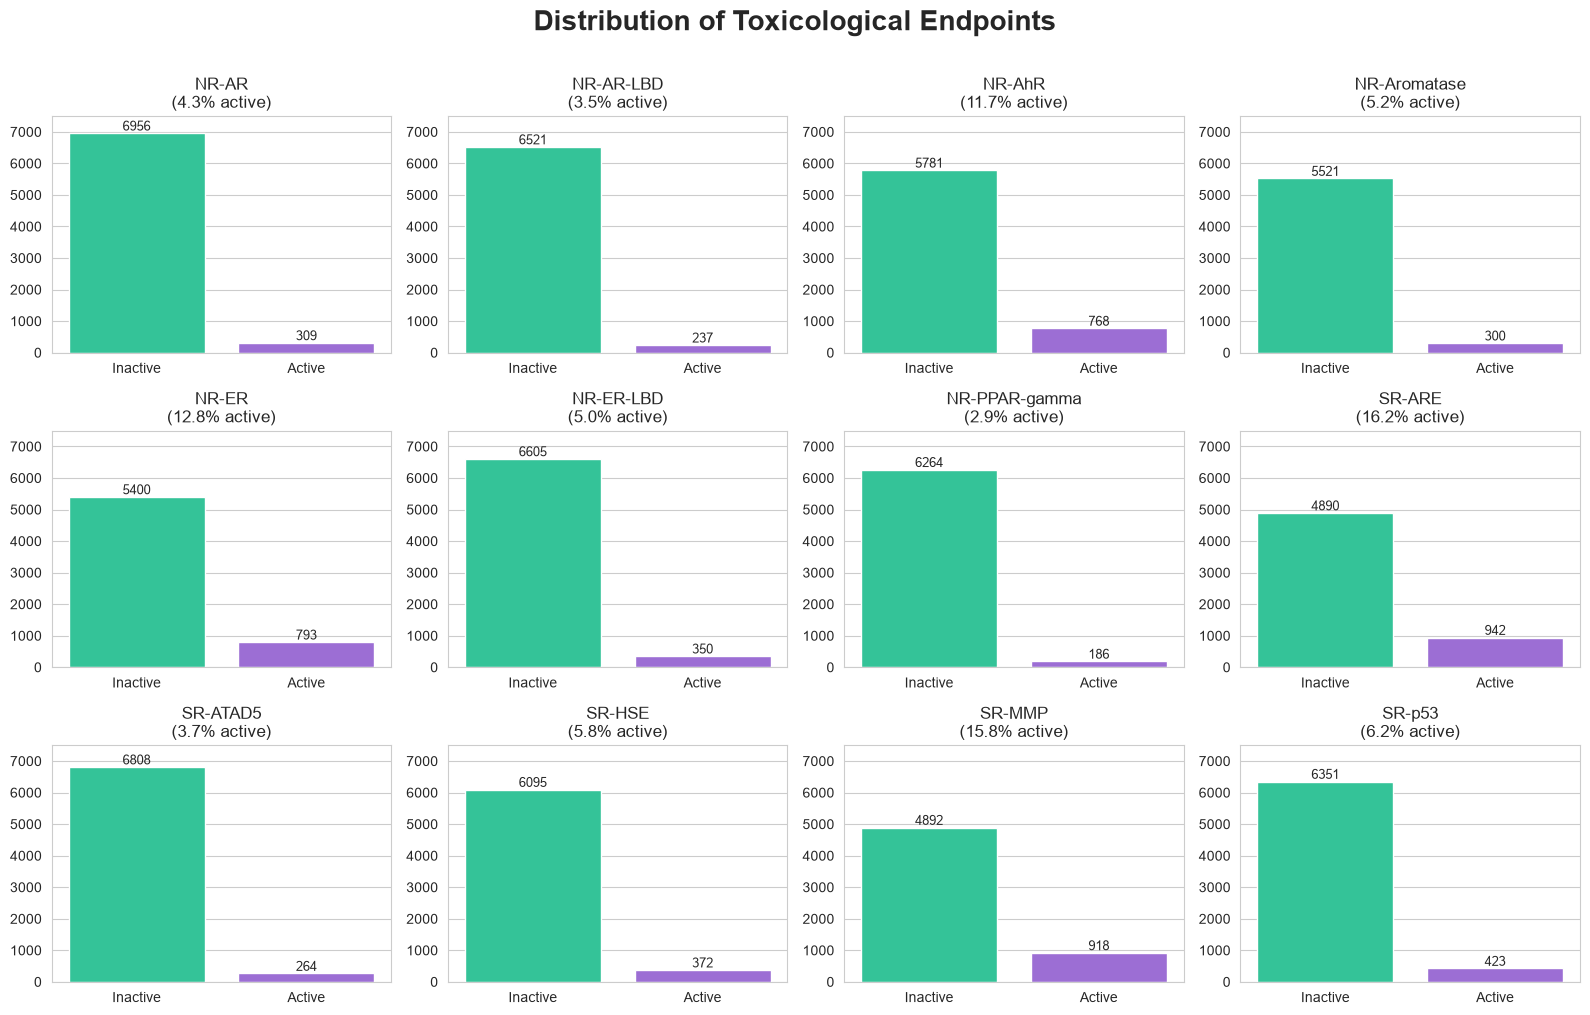

In [10]:
plt.figure(figsize=(16,10))

i = 1

for target in plot_data:
  
  ax = plt.subplot(3, 4, i)
  
  # Calculate % active
  total = target['Inactive'] + target['Active']
  pct_active = (target['Active'] / total) * 100
  
  plt.title(f'{targets[i-1]}\n({pct_active:.1f}% active)', size=12)
  sns.barplot(target, palette=["#1cdba2", "#9b5de5"])
  plt.ylim(0, 7500)
  
  # Add count labels to each bar
  for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9)
    
  i += 1

plt.suptitle('Distribution of Toxicological Endpoints', fontsize=20, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.2.2 - Missing Values

In [11]:
missing_data = pd.DataFrame(
  {'Sample_size': len(target_df) - target_df.isnull().sum(),
   'Nb_missing': target_df.isnull().sum(),
   'Percentage': round((target_df.isnull().sum() / len(target_df))*100, 1)}
)

missing_data = missing_data.sort_values(by='Percentage', ascending=False)
missing_data

,Sample_size,Nb_missing,Percentage
SR-MMP,5810,2021,25.8
NR-Aromatase,5821,2010,25.7
SR-ARE,5832,1999,25.5
NR-ER,6193,1638,20.9
NR-PPAR-gamma,6450,1381,17.6
SR-HSE,6467,1364,17.4
NR-AhR,6549,1282,16.4
NR-AR-LBD,6758,1073,13.7
SR-p53,6774,1057,13.5
NR-ER-LBD,6955,876,11.2


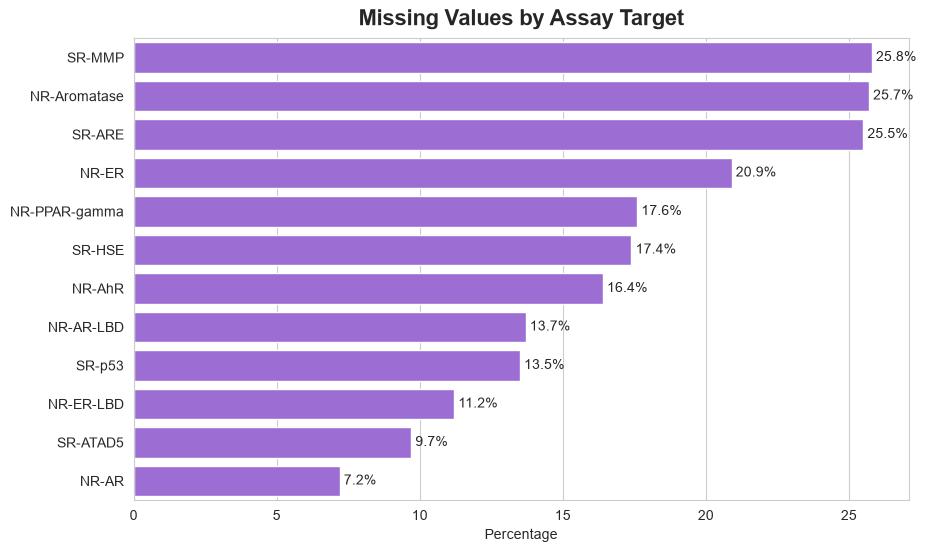

In [12]:
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(missing_data['Percentage'], orient='y', color='#9b5de5', ax=ax)
plt.title('Missing Values by Assay Target', weight='bold', size=16, y=1.01)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.show()

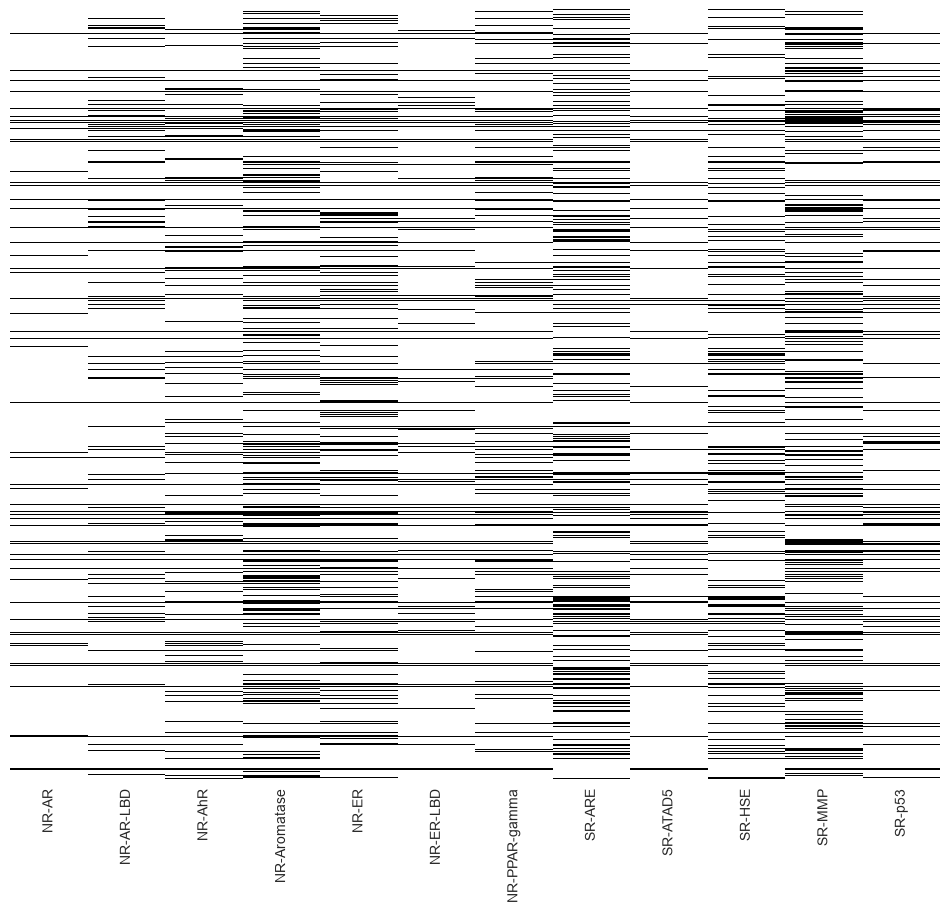

In [13]:
# visualize missing values
plt.figure(figsize=(12,10))
sns.heatmap(target_df.isnull(), yticklabels=False, cbar=False, cmap="gray_r")

plt.show()

### 1.2.3 - Correlations

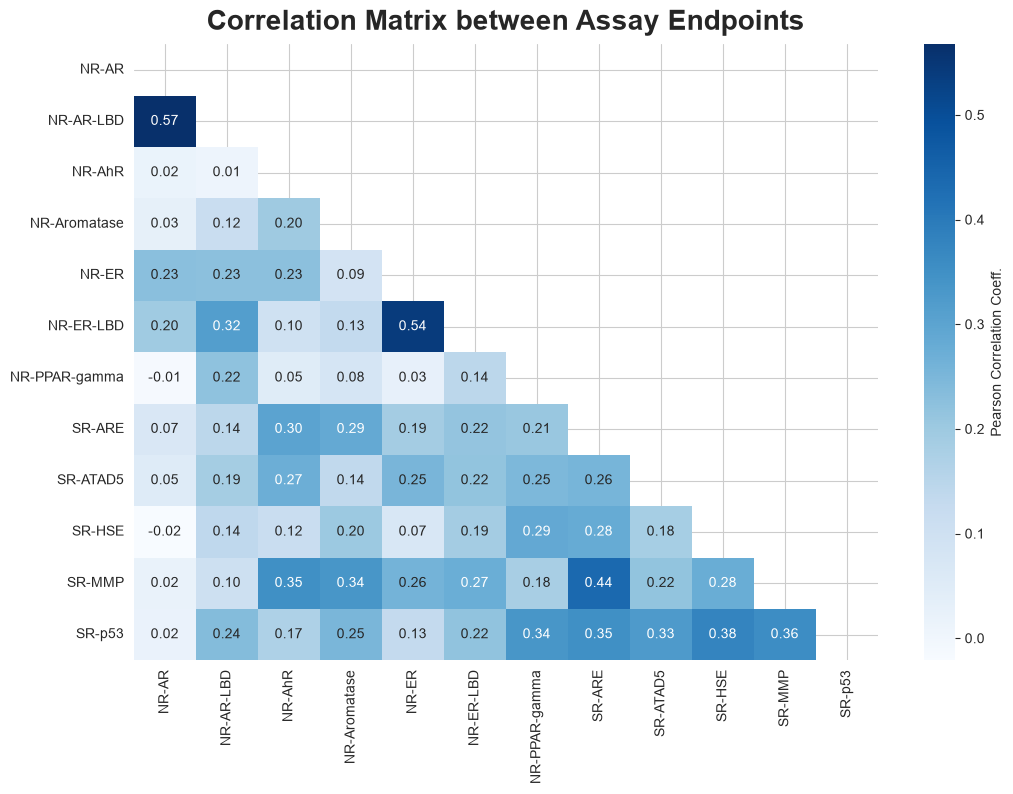

In [14]:
plt.figure(figsize=(12,8))

# returns a boolean matrix with the upper triangle and leading diagonal evaluating to true. this is used to hide this portion of the correlation heatmap
mask = np.triu(np.ones_like(target_df.corr(), dtype=bool))

heatmap = sns.heatmap(target_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='Blues', cbar_kws={'label': 'Pearson Correlation Coeff.'})
plt.title('Correlation Matrix between Assay Endpoints', weight='bold', y=1.01, size=20)

plt.show()

The strongest correlations exist between:

| Target 1 | Target 2 | Correlation | 
|----------|----------|-------------|
| NR-AR-LBD | NR-AR   | 0.57 |
| NR-ER-LBD | NR-ER   | 0.54 |
| SR-MMP | SR-ARE | 0.44 |

The top two correlations are not very surprising considering how closely related AR/AR-LBD & ER/ER-LBD are.

It is interesting to note that SR-MMP and SR-ARE show some evidence of a linear relationship. This makes sense considering how MMP is a marker for mitochondrial toxicity (related to drug-induced liver injury) whilst ARE is an antioxidant response assay looking at oxidative stress (often induced by reactive metabolites).

>* Since the liver plays a key role in breakdown of harmful metabolites, there is likely to be some overlap between the results of the SR-MMP and SR-ARE assays.

---

## 2 - Chemical Data Analysis

The raw Tox21 data only contains smiles strings. We can extract relevant molecular descriptors and visualize the molecules to explore the types of molecules we are working with.

In [15]:
# confirm no duplicate smiles exist in the dataset
data['smiles'].nunique() == len(data)

True

### 2.1 - Visualising Molecules

`RDKit` is an open source Python library for cheminformatics and molecular structure ML applications.

<details>
<summary><b>Read more</b></summary> 

[RDKit Documentation](https://www.rdkit.org/docs/GettingStartedInPython.html)

</details>

Various functions and methods will be used to visualise and extract information from the molecules in the dataset. 

In [16]:
# generate rdkit molecule objects for all molecules in the dataset
PandasTools.AddMoleculeColumnToFrame(data, 'smiles', 'structure')

[18:14:19] WARNING: not removing hydrogen atom without neighbors
[18:14:19] Explicit valence for atom # 8 Al, 6, is greater than permitted
[18:14:19] Explicit valence for atom # 3 Al, 6, is greater than permitted
[18:14:19] Explicit valence for atom # 4 Al, 6, is greater than permitted
[18:14:19] Explicit valence for atom # 4 Al, 6, is greater than permitted
[18:14:19] Explicit valence for atom # 9 Al, 6, is greater than permitted
[18:14:19] Explicit valence for atom # 5 Al, 6, is greater than permitted
[18:14:19] Explicit valence for atom # 16 Al, 6, is greater than permitted
[18:14:19] Explicit valence for atom # 20 Al, 6, is greater than permitted


In [17]:
data.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles,structure
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,<rdkit.Chem.rdchem.Mol object at 0x0000022347D14E40>
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O,<rdkit.Chem.rdchem.Mol object at 0x0000022347D14EB0>
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]3CC[C@@]21C,<rdkit.Chem.rdchem.Mol object at 0x0000022347D14F20>
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,<rdkit.Chem.rdchem.Mol object at 0x0000022347D14F90>
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O,<rdkit.Chem.rdchem.Mol object at 0x0000022347D15000>


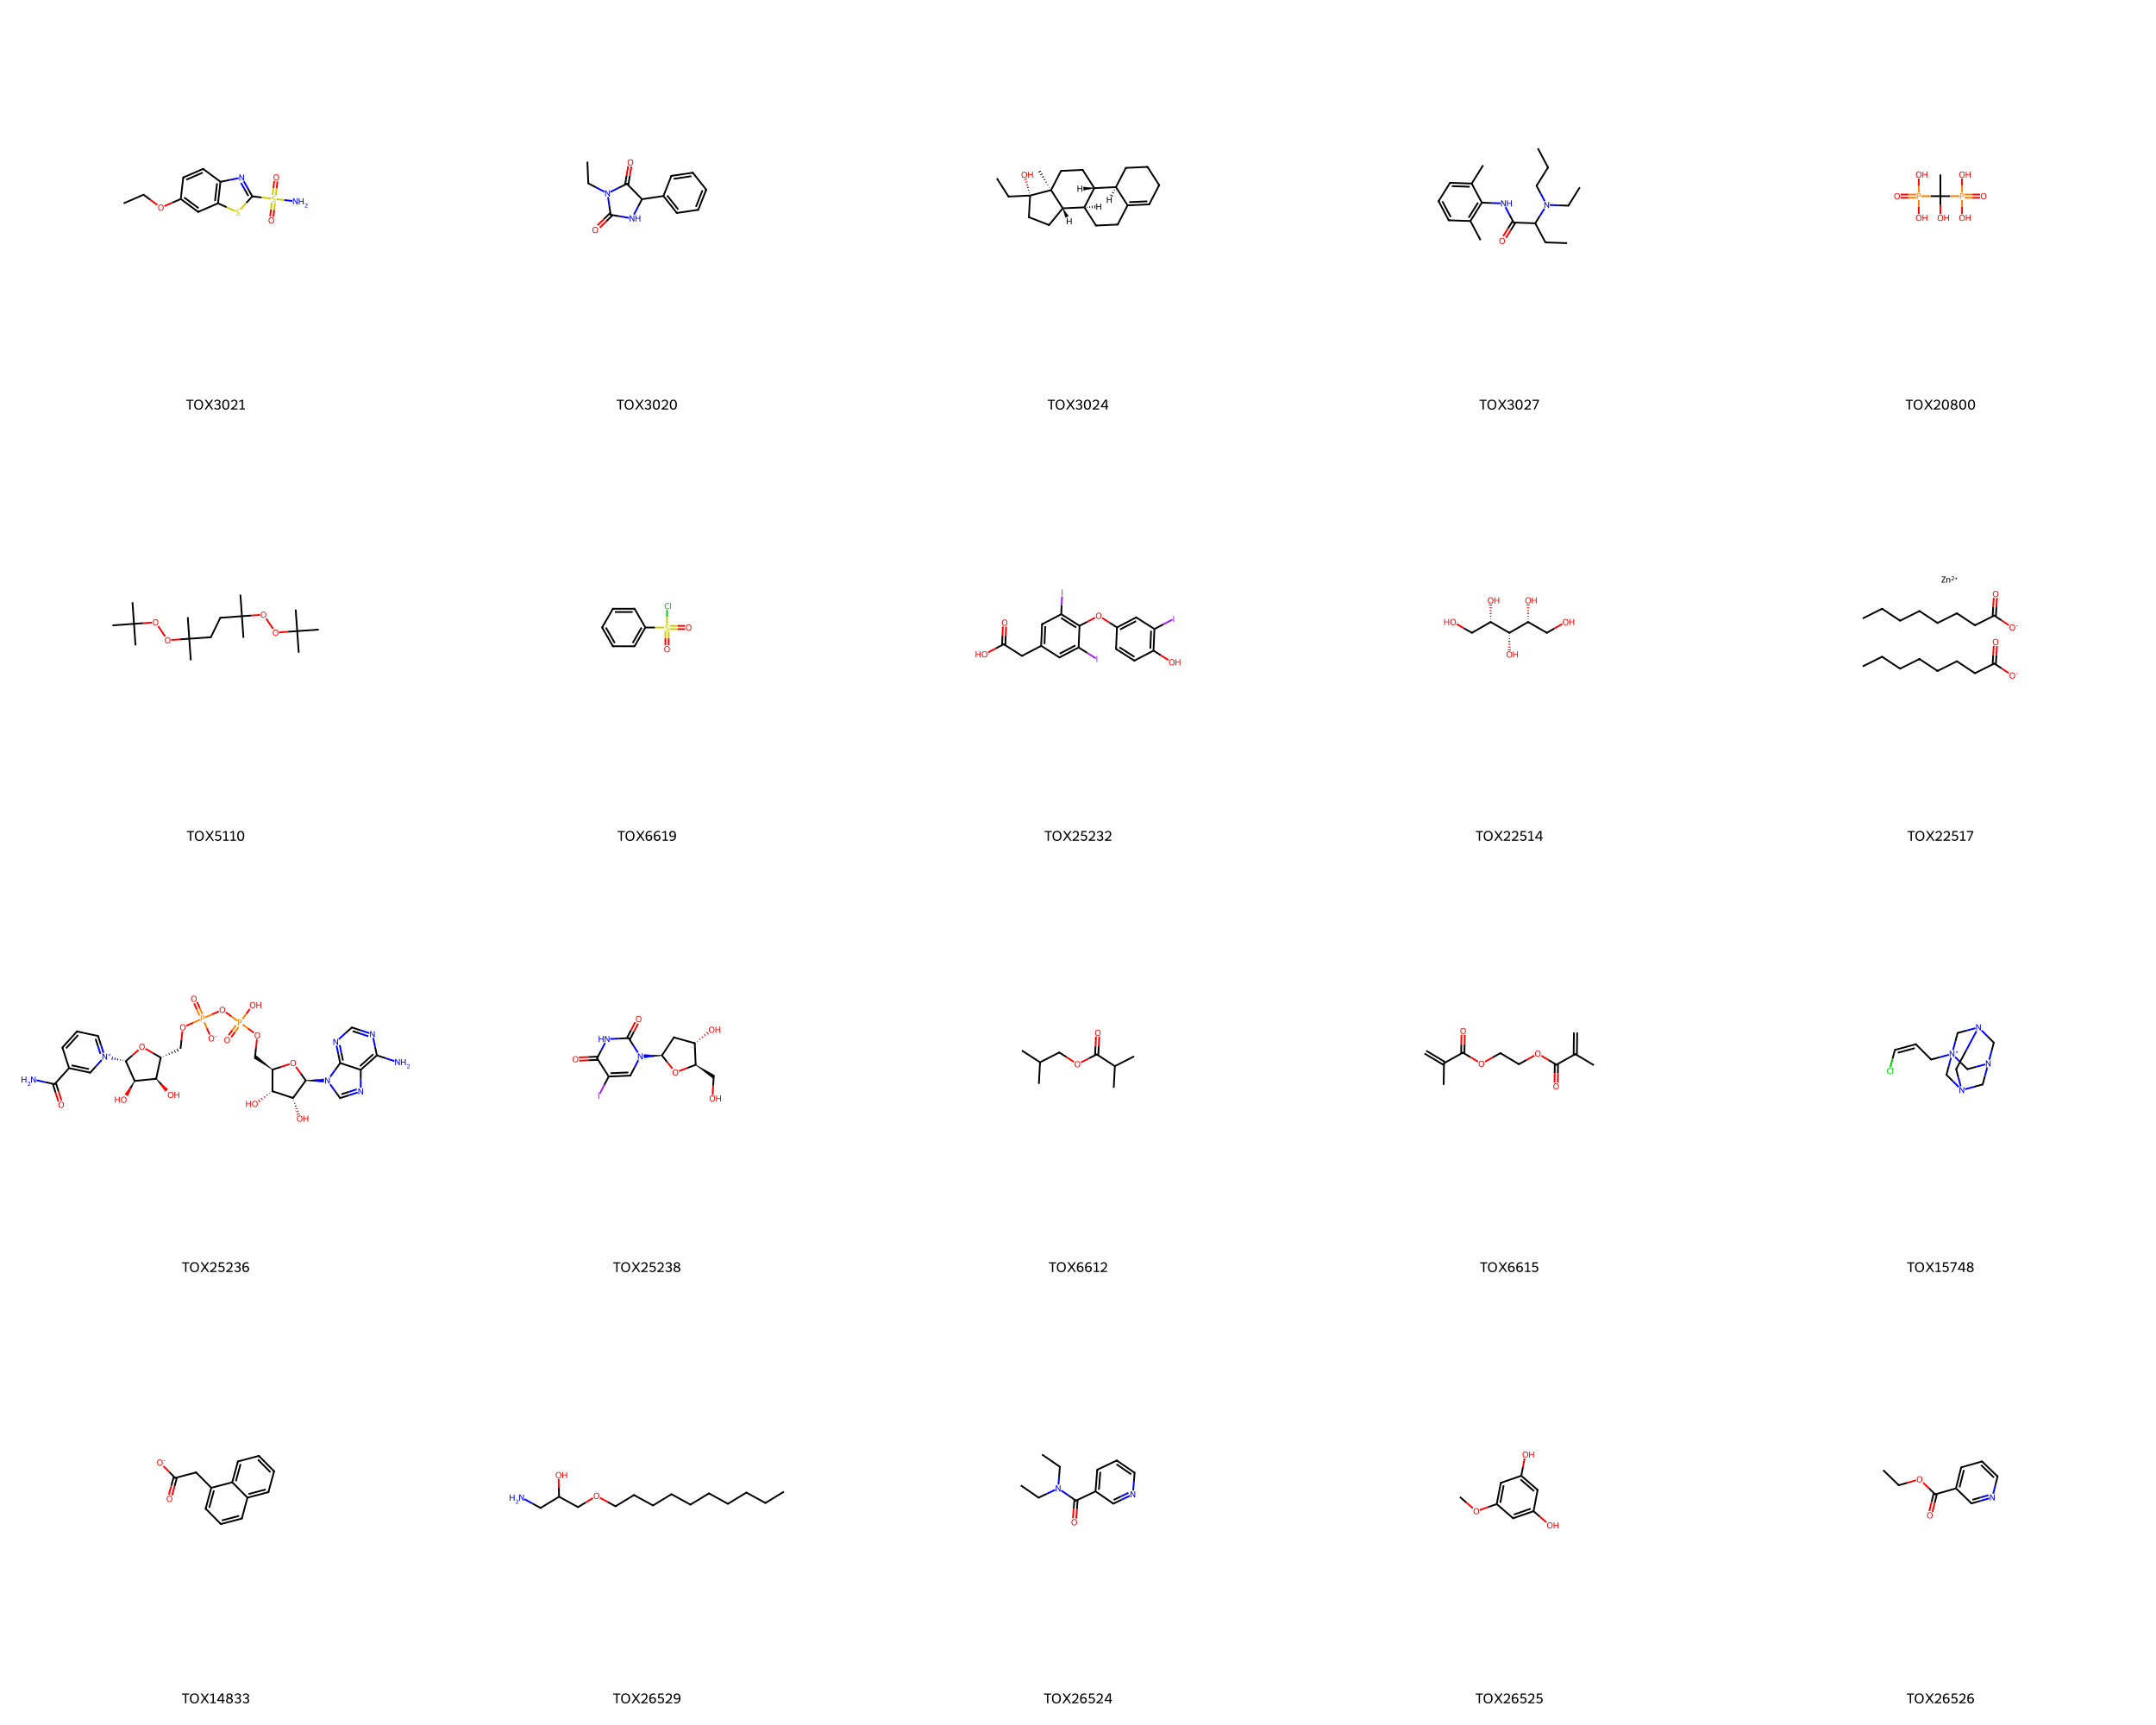

In [18]:
# visualize the first 20 molecules
Draw.MolsToGridImage([x for x in data['structure']][:20], maxMols=100,
                     legends=[str(x) for x in data['mol_id']], subImgSize=(500,500), molsPerRow=5)

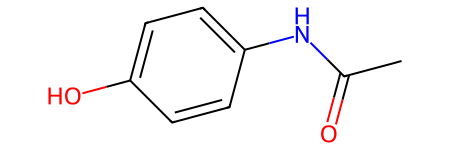

In [19]:
# any molecule can be converted from a smiles string and visualized 

def visualise_molecule(smiles):
  '''A function to output an image of a molecule from its smiles string'''
  return AllChem.MolFromSmiles(smiles)

paracetamol = visualise_molecule('C1C(O)=CC=C(NC(=O)C)C=1')
paracetamol

### 2.2 - Featurising the Molecules

To develop strong predictive models for each target, it will be necessary to create feature sets for each molecule in the database.

1. Simple medicinal chemistry molecular descriptors can be calculated directly from smiles strings.

2. Extended Connectivity FingerPrints (ECFPs) can be used to create a vector for every molecule in the dataset to encode sub-structure information. (_more on this in the section 2.3.2_)

---

### 2.3.1 - Calculating Molecular Descriptors

A number of commonly used medicinal chemistry molecular descriptors can be calculated from the smiles strings inputs with the help of the `RDKit` library.

| Descriptor | Description |
|------------|-------------|
| MolWeight  | Molecular weight ($\text{g mol}^{-1}$) |
| LogP | Partition coefficient (octanol:water). A measure of a compound's lipophilicity |
| TPSA | Topological Polar Surface Area (Å). A measure of the total SA of polar atoms and their bounded H atoms |
| NumHDonors | The number of H atoms bonded to a highly electronegative atom |
| NumHAcceptors | The number of highly electronegative atoms with free lone pairs |
| NumRotatableBonds | The number of single bonds that are not part of a ring connecting two atoms, which each have at least one other nonterminal substituent |
| NumAtoms | The total number of atoms |
| NumHeavyAtoms | The number of all non-H atoms |
| NumRings | The number of rings |
| NumAromaticRings | The number of aromatic rings (carbocycles+heterocycles) |
| FractionCSP3 | The number of Sp3-hybridised carbon atoms. As CSp3 approaches 1, the molecule moves further and further away from planarity and into 3-dimensional space. The concept of 'escaping flatland' is well-known and remains an area of active interest in drug discovery. Precise control over 3-dimensional structure can revolutionize drug discovery and unlock new therapeutic mechanisms. As a result, compounds with a high CSp3 fraction are often more interesting candidates. |
| BertzCT | BertzCT index combines two main factors to calculate a single complexity score: Bonding complexity (counts the number and types of bonds and connections between atoms) and Heteroatom distribution (looks at where atoms other than carbon and hydrogen are placed in the molecular graph). |

In [20]:
def calculate_molecular_descriptors(mol):
    """Calculate basic molecular descriptors"""
    if mol is None:
        return None
    
    try:
        descriptors = {
            'MolWeight': Descriptors.MolWt(mol),
            'LogP': Descriptors.MolLogP(mol),
            'TPSA': Descriptors.TPSA(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol),
            'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
            'NumAtoms': mol.GetNumAtoms(),
            'NumHeavyAtoms': mol.GetNumHeavyAtoms(),
            'NumRings': Descriptors.RingCount(mol),
            'NumAromaticRings': Descriptors.NumAromaticRings(mol),
            'FractionCSP3': Descriptors.FractionCSP3(mol),
            'BertzCT': GraphDescriptors.BertzCT(mol)
        }
        return descriptors
    except:
        return None

In [21]:
calculate_molecular_descriptors(paracetamol)

{'MolWeight': 151.165,
 'LogP': 1.3505999999999998,
 'TPSA': 49.33,
 'NumHDonors': 2,
 'NumHAcceptors': 2,
 'NumRotatableBonds': 1,
 'NumAtoms': 11,
 'NumHeavyAtoms': 11,
 'NumRings': 1,
 'NumAromaticRings': 1,
 'FractionCSP3': 0.125,
 'BertzCT': 253.29949758389105}

In [22]:
# calculate common medchem descriptors for the entire dataset of molecules

descriptors_list = []
for mol in data['structure']:
    if mol is not None:
        desc = calculate_molecular_descriptors(mol)
        descriptors_list.append(desc)
    else:
        descriptors_list.append({})

# add to dataframe
desc_df = pd.DataFrame(descriptors_list, index=data.index)
df_descriptors = pd.concat([data, desc_df], axis='columns')

print(f"Descriptors calculated for {desc_df.notna().all(axis=1).sum():,} molecules")

Descriptors calculated for 7,823 molecules


In [23]:
df_descriptors.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles,structure,MolWeight,LogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,NumAtoms,NumHeavyAtoms,NumRings,NumAromaticRings,FractionCSP3,BertzCT
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,<rdkit.Chem.rdchem.Mol object at 0x0000022347D14E40>,258.324,1.34240,82.28,1.0,5.0,3.0,16.0,16.0,2.0,2.0,0.222222,618.715848
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O,<rdkit.Chem.rdchem.Mol object at 0x0000022347D14EB0>,204.229,1.29940,49.41,1.0,2.0,2.0,15.0,15.0,2.0,1.0,0.272727,388.834212
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]3CC[C@@]21C,<rdkit.Chem.rdchem.Mol object at 0x0000022347D14F20>,288.475,5.09030,20.23,1.0,1.0,1.0,21.0,21.0,4.0,0.0,0.900000,452.754767
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,<rdkit.Chem.rdchem.Mol object at 0x0000022347D14F90>,276.424,3.75244,32.34,1.0,2.0,7.0,20.0,20.0,1.0,1.0,0.588235,422.366186
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O,<rdkit.Chem.rdchem.Mol object at 0x0000022347D15000>,206.027,-0.99220,135.29,5.0,3.0,2.0,11.0,11.0,0.0,0.0,1.000000,206.825129


In [24]:
desc_df.describe()

,MolWeight,LogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,NumAtoms,NumHeavyAtoms,NumRings,NumAromaticRings,FractionCSP3,BertzCT
count,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000,7823.000000
mean,276.144155,2.373943,59.472201,1.224978,3.473987,4.302697,18.567813,18.566918,1.772721,1.101496,0.458506,491.594142
std,164.732356,2.304307,57.794990,1.916035,3.115448,4.464772,11.309695,11.309542,1.667745,1.095971,0.325090,438.172581
min,9.012000,-17.406400,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,165.236000,1.149350,26.300000,0.000000,2.000000,1.000000,11.000000,11.000000,1.000000,0.000000,0.181818,190.838854
50%,240.302000,2.365500,46.530000,1.000000,3.000000,3.000000,16.000000,16.000000,1.000000,1.000000,0.416667,387.870648
75%,343.044000,3.653150,77.030000,2.000000,4.000000,6.000000,23.000000,23.000000,3.000000,2.000000,0.726136,678.330609
max,1877.664000,22.611800,777.980000,30.000000,46.000000,47.000000,132.000000,132.000000,30.000000,12.000000,1.000000,5967.702561


#### 2.3.1.1 - Exploring Large Molecules

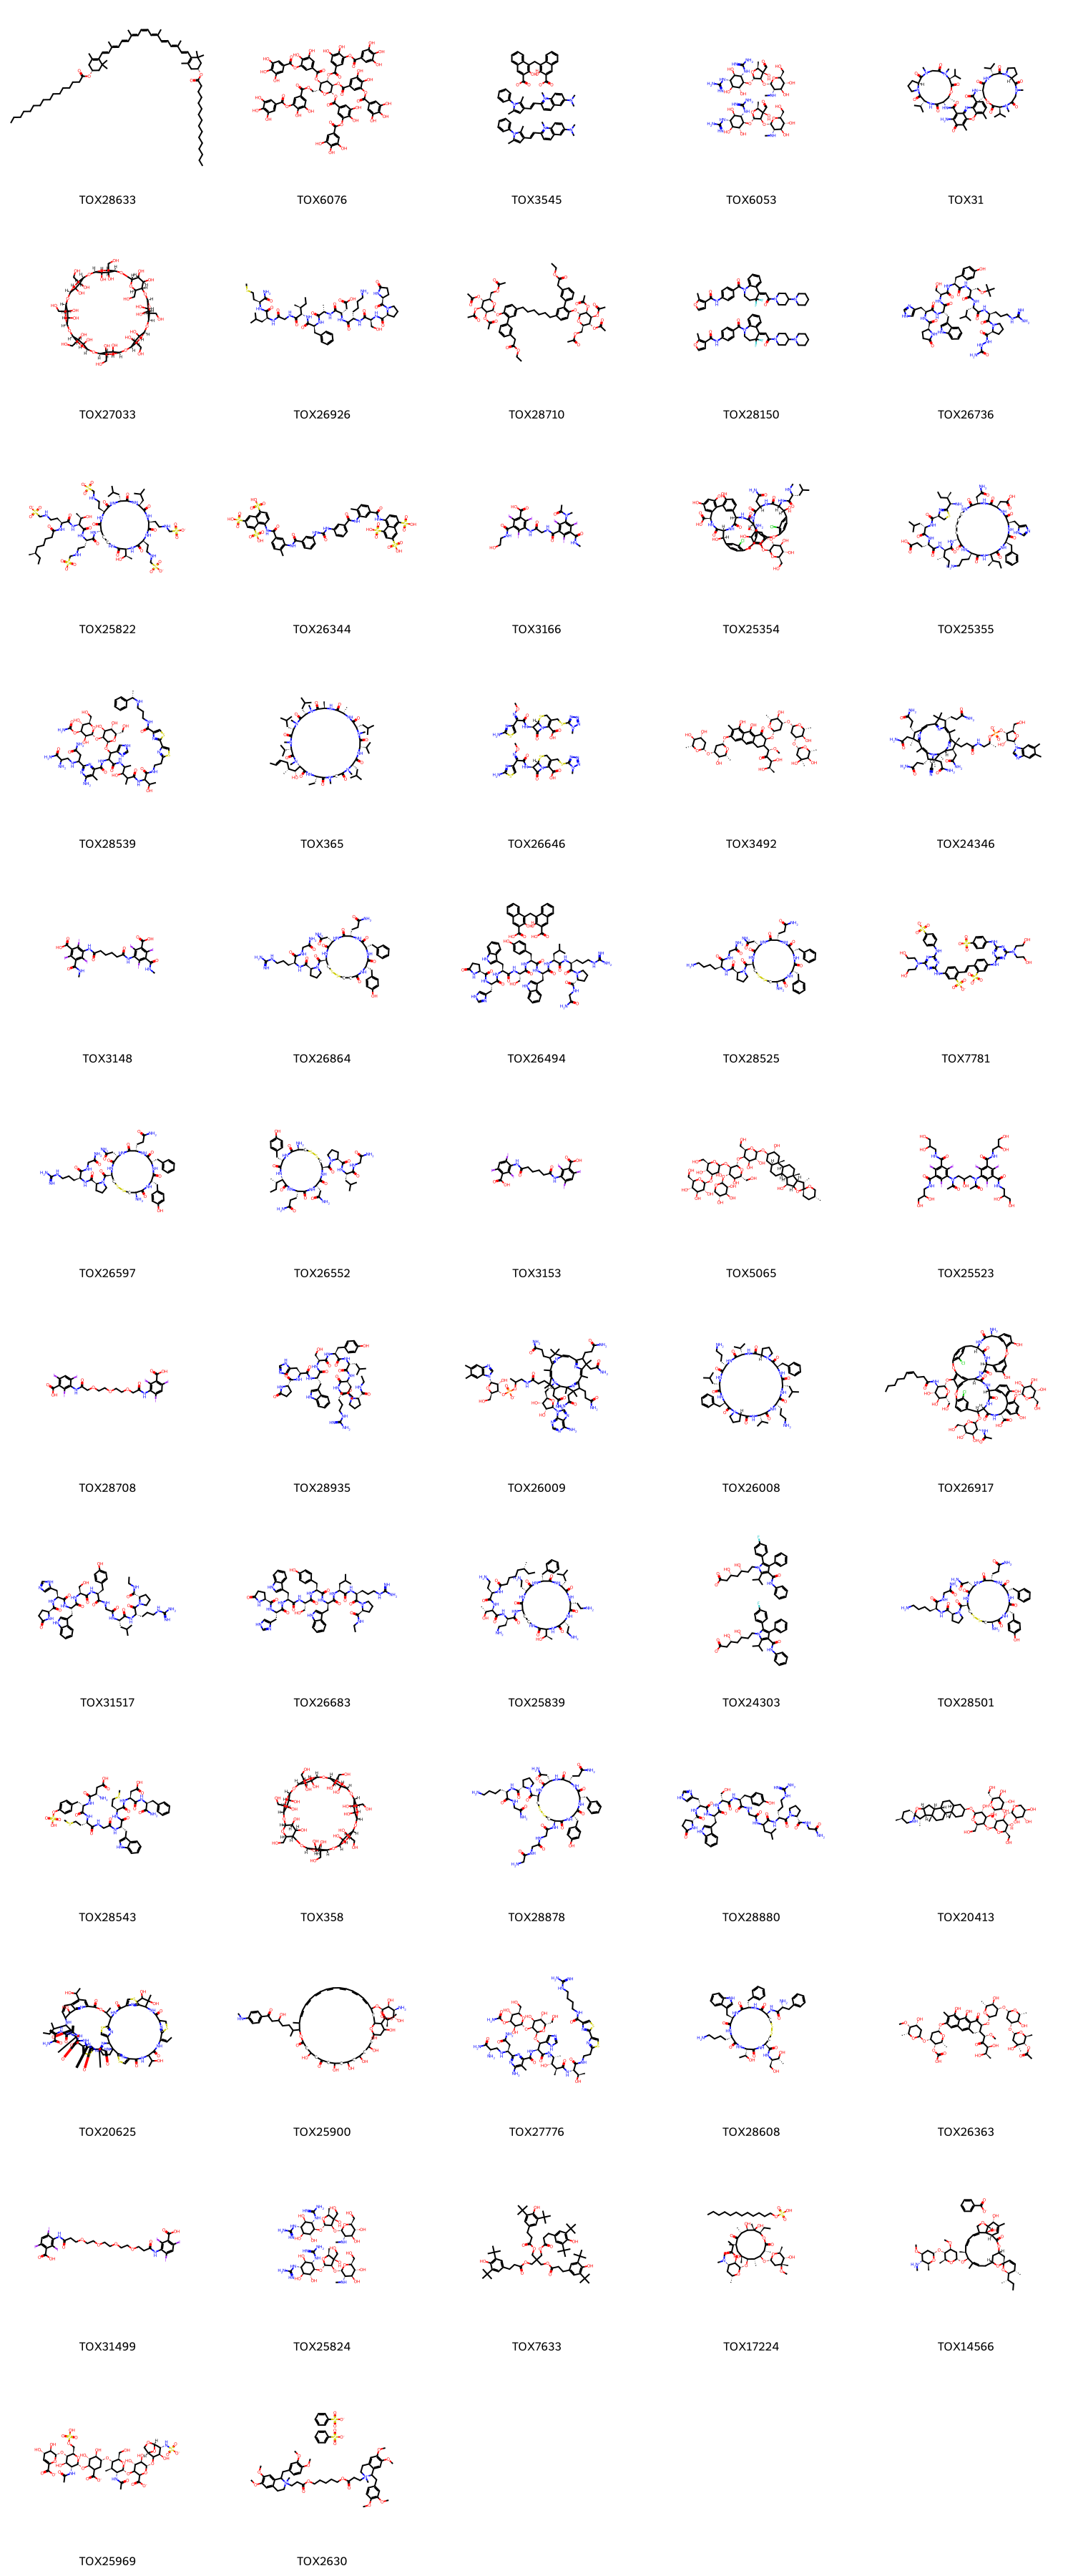

In [25]:
large_molecules = df_descriptors[df_descriptors['MolWeight'] > 1000]

Draw.MolsToGridImage([x for x in large_molecules['structure']], maxMols=100,
                     legends=[str(x) for x in large_molecules['mol_id']], subImgSize=(300,300), molsPerRow=5)

#### 2.3.1.2 - Molecular Descriptor EDA

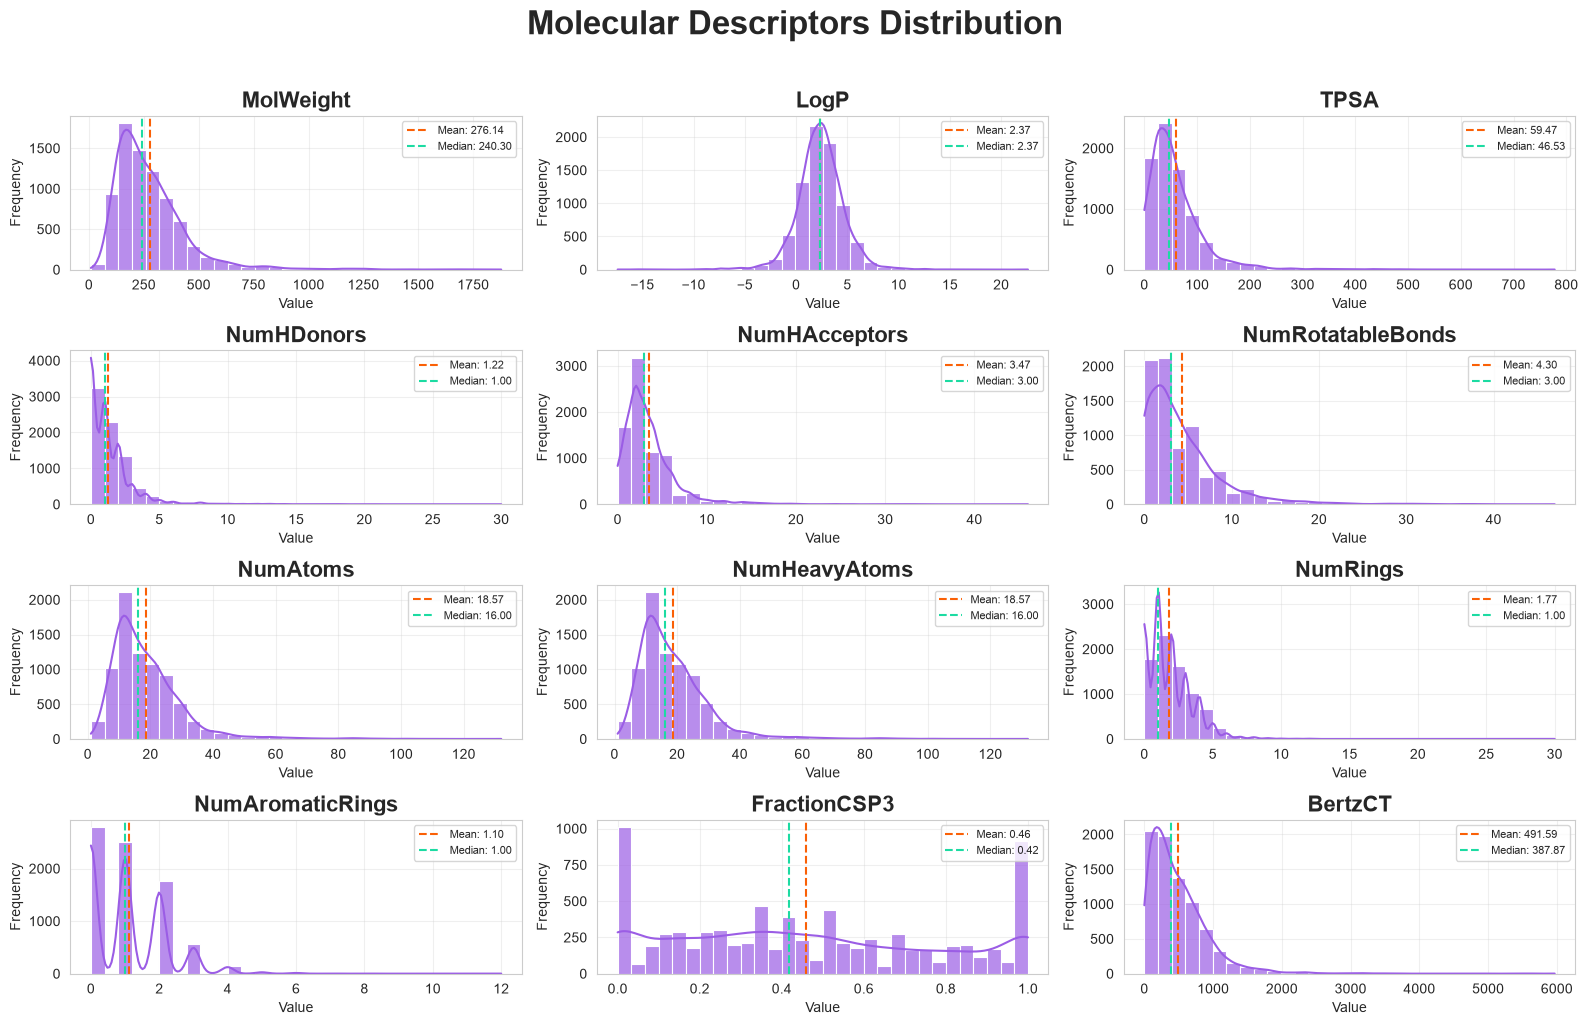

In [26]:
numeric_descriptors = ['MolWeight', 'LogP', 'TPSA', 'NumHDonors', 
                       'NumHAcceptors', 'NumRotatableBonds', 'NumAtoms',
                       'NumHeavyAtoms', 'NumRings', 'NumAromaticRings', 
                       'FractionCSP3', 'BertzCT']

fig, axes = plt.subplots(4, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, descriptor in enumerate(numeric_descriptors):
    if idx < len(axes):
        ax = axes[idx]
        descriptor_data = df_descriptors[descriptor].dropna()
        
        # Histogram
        sns.histplot(descriptor_data, bins=30, alpha=0.7, 
               color='#9b5de5', kde=True, ax=ax)
        
        # Add statistical lines
        ax.axvline(descriptor_data.mean(), color="#fa6006", linestyle='--', 
                  label=f'Mean: {descriptor_data.mean():.2f}')
        ax.axvline(descriptor_data.median(), color='#1cdba2', linestyle='--', 
                  label=f'Median: {descriptor_data.median():.2f}')
        
        ax.set_title(descriptor, fontsize=16, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Molecular Descriptors Distribution', fontsize=24, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

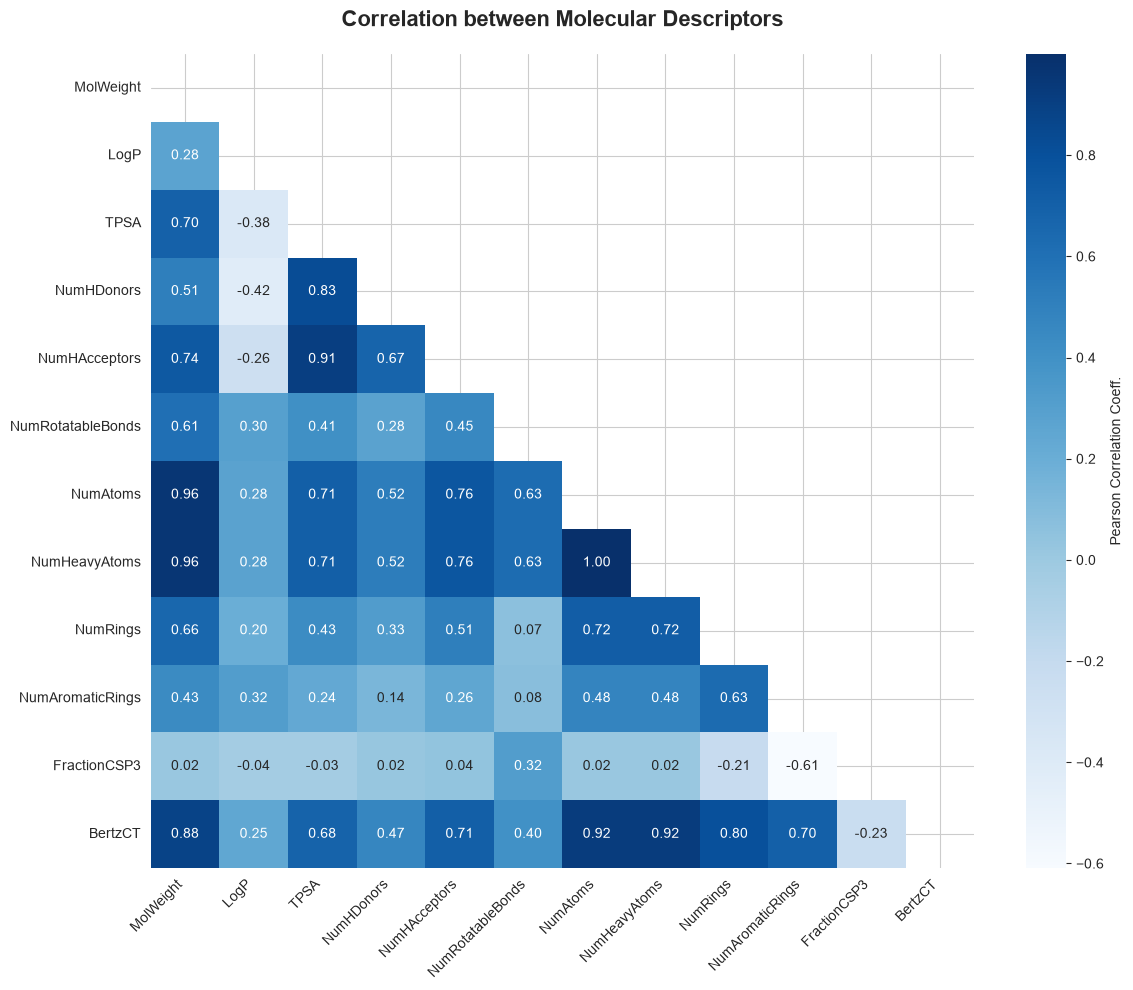


 Strong correlations between descriptors (|r| > 0.7):


,Descriptor 1,Descriptor 2,Correlation
11,NumAtoms,NumHeavyAtoms,0.999982
2,MolWeight,NumHeavyAtoms,0.958608
1,MolWeight,NumAtoms,0.958583
15,NumHeavyAtoms,BertzCT,0.922333
13,NumAtoms,BertzCT,0.922320
5,TPSA,NumHAcceptors,0.910737
3,MolWeight,BertzCT,0.881935
4,TPSA,NumHDonors,0.828390
16,NumRings,BertzCT,0.804979
9,NumHAcceptors,NumHeavyAtoms,0.763828


In [27]:
# Calculate correlation matrix
desc_corr = df_descriptors[numeric_descriptors].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(desc_corr, dtype=bool))
sns.heatmap(desc_corr, mask=mask, annot=True, cmap='Blues',
            fmt='.2f', cbar_kws={'label': 'Pearson Correlation Coeff.'})

plt.title('Correlation between Molecular Descriptors', 
          fontsize=16, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify strong correlations between descriptors
print("\n Strong correlations between descriptors (|r| > 0.7):")
strong_desc_corr = []
for i in range(len(desc_corr.columns)):
    for j in range(i+1, len(desc_corr.columns)):
        corr = desc_corr.iloc[i, j]
        if abs(corr) > 0.7 and not np.isnan(corr):
            strong_desc_corr.append({
                'Descriptor 1': desc_corr.columns[i],
                'Descriptor 2': desc_corr.columns[j],
                'Correlation': corr
            })

if strong_desc_corr:
    strong_desc_df = pd.DataFrame(strong_desc_corr)
    display(strong_desc_df.sort_values('Correlation', ascending=False))

These correlations are expected. Multi-collinearity will be a factor in the complete feature set, but this can be reduced during fine-tuning.

---

#### 2.3.1.3 - Learnings from the EDA on the Tox21 Molecules

* Mwt range spans the small to intermediate molecular size regime 9 - 1,878 Da, with the majority clustering around ~250 Da.

* The largest molecules in the dataset are typically macrocycles, oligosaccharides, oligopeptides or resemble PROTAC structures (linkers connecting two moieties).

>This lends support to the idea of expanding the radius of any ECFP featurising to capture extended sub-structures for these larger molecules.

* Lipophilicity shows a normal distribution, with a mean of 2.37 (typical for drug-like lipophilicity profiles).

* All of the structural descriptors (TPSA, number of bonds/atoms) are right-skewed due to the influence of the largest molecules in the dataset.

* The C(SP3) fraction appears to be bimodal. The majority of molecules in the dataset are either entirely planar or entirely 3-dimensional. Between these two modes, there is a roughly uniform spread of sp3 hybridised carbon fractions represented across the molecules of the dataset.

---

### 2.3.2 - Calculating Extended Connectivity Fingerprints

**A brief explanation of ECFPs:**

[Extended Connectivity Fingerprints (ECFPs)](https://pubs.acs.org/jcisd8/article-abstract/50/5/742/1231687/Extended-Connectivity-FingerprintsExtended) are a class of topological fingerprints for molecular characterisation. ECFPs were developed _specifically_ for structure−activity modeling. 

A fingerprint is generated using the Morgan algorithm as a baseline. Every atom begins with an initial identifier: a hash of its local properties (atomic number, degree, charge, attached hydrogen count, ring membership). This is the base-case: **radius 0**. Each atom only knows about itself at this point.

Then you begin iterating outwards. At each round, every atom's identifier gets recomputed by hashing its current identifier together with its neighbours' identifiers and the bond types connecting them. One round in, each atom's identifier encodes everything within one bond of it, a small circular neighbourhood. Two rounds in, it covers two bonds. Keep going and the neighbourhood keeps growing, which is why these are often referred to as *circular* fingerprints: you're expanding a sphere around each atom, one shell at a time. 

>Iteration stops at a chosen radius, typically 2 or 3. ECFP4 denotes a fingerprint that uses radius 2 (diameter 4), whilst ECFP6 uses radius 3 (diameter 6). This means larger radii can encapsulate longer-range substructure information which could be important for larger molecules.


![ECFP-diagram](ecfp-diagram.png)

**Figure 1.** [Illustration of an ECFP-6 fingerprint for an atom in benzamide](https://medium.com/@musicalchemist/from-theory-to-code-a-deep-dive-into-molecular-extended-connectivity-fingerprints-ecfps-with-da1ed436925e)

This information is then collapsed into a vector of bits of a pre-defined size, encoding sub-structural information.

A complete fingerprint is encoded by a pre-defined number of bits as a vector. If 32 bits were used, a possible fingerprint of a molecule could be: (0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0). Typically, 1024 or 2048 bits are used (but this can be adjusted depending on the task).

>_Note:_ a count of each substructure can also be encoded into the fingerprint, known as a CountFingerprint. This can be useful for molecules containing many repeated substructures.

---

As an initial baseline, ECFP-6 will be used, encoding with 2048 bits.

In [28]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)

def mol_to_ecfp(mol):
    """Convert an RDKit mol object to a count ECFP fingerprint using rdFingerprintGenerator."""
    if mol is None:
        return np.zeros(2048)
    return np.array(morgan_gen.GetCountFingerprintAsNumPy(mol))

In [29]:
# Generate ECFP fingerprints for all molecules
ecfp_matrix = np.array([mol_to_ecfp(mol) for mol in data['structure']])
ecfp_df = pd.DataFrame(ecfp_matrix,
                       columns=[f'ECFP_{i}' for i in range(ecfp_matrix.shape[1])],
                       index=data.index)

print(f"ECFP matrix shape: {ecfp_df.shape}")

ECFP matrix shape: (7831, 2048)


#### 2.3.2.1 - Pre-processing

Initially, the `NR-AhR` (aryl hydrocarbon receptor) assay result will be our target. This target is appropriate as a first-pass toxicity predictor as these receptors are not typically therapeutic targets. Any molecules which show activity against this receptor are likely to be toxic.

We can also include the 12 medicinal chemistry descriptors into the feature set as this may improve performance and assist in the interpretability of the predictions.

In [30]:
# Descriptor column names (from calculate_molecular_descriptors)
descriptor_cols = ['MolWeight', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors',
                   'NumRotatableBonds', 'NumAtoms', 'NumHeavyAtoms', 'NumRings', 'NumAromaticRings', 
                   'FractionCSP3', 'BertzCT']

# Combine descriptors + ECFP into a single feature matrix
X = pd.concat([desc_df[descriptor_cols], ecfp_df], axis=1)

# Target: NR-AhR (binary classification)
y = data['NR-AhR']

# Drop rows where target or any descriptor is NaN
valid_mask = y.notna() & X.notna().all(axis=1)
X = X[valid_mask]
y = y[valid_mask].astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Class balance: {y.mean():.3f} active")

Feature matrix shape: (6542, 2060)
Target distribution:
NR-AhR
0    5774
1     768
Name: count, dtype: int64
Class balance: 0.117 active


In [31]:
X.head()

MolWeight     LogP    TPSA  NumHDonors  NumHAcceptors  NumRotatableBonds  \
0    258.324  1.34240   82.28         1.0            5.0                3.0   
1    204.229  1.29940   49.41         1.0            2.0                2.0   
3    276.424  3.75244   32.34         1.0            2.0                7.0   
4    206.027 -0.99220  135.29         5.0            3.0                2.0   
5    290.444  4.81720   36.92         0.0            4.0                7.0   

   NumAtoms  NumHeavyAtoms  NumRings  NumAromaticRings  FractionCSP3  \
0      16.0           16.0       2.0               2.0      0.222222   
1      15.0           15.0       2.0               1.0      0.272727   
3      20.0           20.0       1.0               1.0      0.588235   
4      11.0           11.0       0.0               0.0      1.000000   
5      20.0           20.0       0.0               0.0      1.000000   

      BertzCT  ECFP_0  ECFP_1  ECFP_2  ECFP_3  ECFP_4  ECFP_5  ECFP_6  ECFP_7  \
0  618.715848     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1  388.834212     0.0     0.0     0.0     0.0     0.0     1.0     0.0     0.0   
3  422.366186     0.0     1.0     0.0     0.0     1.0     0.0     0.0     0.0   
4  206.825129     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5  251.832448     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

   ECFP_8  ECFP_9  ECFP_10  ECFP_11  ECFP_12  ECFP_13  ECFP_14  ECFP_15  \
0     0.0     0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1     0.0     0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3     0.0     0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4     0.0     0.0      0.0      0.0      0.0      0.0      0.0      0.0   
5     0.0     0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   ECFP_16  ECFP_17  ECFP_18  ECFP_19  ECFP_20  ECFP_21  ECFP_22  ECFP_23  \
0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
5      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   ECFP_24  ECFP_25  ECFP_26  ECFP_27  ECFP_28  ECFP_29  ECFP_30  ECFP_31  \
0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1      0.0      1.0      0.0      1.0      0.0      0.0      0.0      0.0   
3      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
5      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   ECFP_32  ECFP_33  ECFP_34  ECFP_35  ECFP_36  ECFP_37  ECFP_38  ECFP_39  \
0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1      0.0      0.0      1.0      0.0      0.0      0.0      0.0      0.0   
3      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
5      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   ECFP_40  ECFP_41  ECFP_42  ECFP_43  ECFP_44  ECFP_45  ECFP_46  ECFP_47  \
0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
5      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   ECFP_48  ECFP_49  ECFP_50  ECFP_51  ECFP_52  ECFP_53  ECFP_54  ECFP_55  \
0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0 

## 2.4 Train-Val-Test Split

A 80-10-10 split will be performed to ensure a sufficiently large training set whilst holding out an appropriate number of molecules for validation and testing. Each split will be stratified to ensure each set has the same proportion of active/in-active molecules.

In [32]:
# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: split temp into 50/50 -> 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 5233 samples
Val:   654 samples
Test:  655 samples


In [33]:
print(f"Train: {y_train.value_counts()}")
print(f"Val:   {y_val.value_counts()}")
print(f"Test:  {y_test.value_counts()}")

Train: NR-AhR
0    4619
1     614
Name: count, dtype: int64
Val:   NR-AhR
0    577
1     77
Name: count, dtype: int64
Test:  NR-AhR
0    578
1     77
Name: count, dtype: int64


There is moderate imbalance across each set (only ~13% of molecules are active). This should not be a huge concern for gradient boosted classifier models - particularly XGBoosted Forests.

In [34]:
# standard scaling applied to the medchem descriptors

scaler = StandardScaler()

# Scale only descriptor columns
X_train_desc_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[descriptor_cols]),
    columns=descriptor_cols,
    index=X_train.index
)
X_val_desc_scaled = pd.DataFrame(
    scaler.transform(X_val[descriptor_cols]),
    columns=descriptor_cols,
    index=X_val.index
)
X_test_desc_scaled = pd.DataFrame(
    scaler.transform(X_test[descriptor_cols]),
    columns=descriptor_cols,
    index=X_test.index
)

# Get ECFP columns (everything not in descriptor_cols)
ecfp_cols = [c for c in X_train.columns if c not in descriptor_cols]

# Recombine: scaled descriptors + unscaled ECFP
X_train_scaled = pd.concat([X_train_desc_scaled, X_train[ecfp_cols]], axis=1)
X_val_scaled = pd.concat([X_val_desc_scaled, X_val[ecfp_cols]], axis=1)
X_test_scaled = pd.concat([X_test_desc_scaled, X_test[ecfp_cols]], axis=1)

In [35]:
y_train.shape

(5233,)

---

## 2.5 - Identifying the Best Classifier Algorithm

The `lazypredict` library can be used to efficiently identify algorithms which seem to perform the best for this task.

In [36]:
# LazyClassifier runs many classifiers and ranks them
clf = LazyClassifier(verbose=0, 
                     ignore_warnings=True, 
                     custom_metric=None, 
                     cv=5, 
                     n_jobs=-1)

# Fit on train, evaluate on validation set
models, predictions = clf.fit(X_train_scaled, X_val_scaled, y_train, y_val)

High-dimensional dataset (2060 features). Some models may be slow or fail. Consider dimensionality reduction.


In [37]:
top_models = models.sort_values('ROC AUC', ascending=False).head(10)
top_models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Accuracy CV Mean,Accuracy CV Std,Balanced Accuracy CV Mean,Balanced Accuracy CV Std,ROC AUC CV Mean,ROC AUC CV Std,F1 Score CV Mean,F1 Score CV Std,Precision CV Mean,Precision CV Std,Recall CV Mean,Recall CV Std,Time Taken
Model,,,,,,,,,,,,,,,,,,,
RandomForestClassifier,0.908257,0.644151,0.904060,0.889317,0.899413,0.908257,0.905407,0.007248,0.615910,0.024139,0.888771,0.028358,0.880892,0.010606,0.899644,0.015203,0.905407,0.007248,9.579190
ExtraTreesClassifier,0.915902,0.670992,0.900223,0.900121,0.910682,0.915902,0.903114,0.006570,0.616725,0.027844,0.881763,0.024244,0.879442,0.010978,0.892413,0.012099,0.903114,0.006570,17.152413
XGBClassifier,0.908257,0.694794,0.892728,0.898321,0.897018,0.908257,0.910184,0.007223,0.704018,0.035202,0.884110,0.019519,0.900875,0.010305,0.899644,0.010431,0.910184,0.007223,8.144776
LGBMClassifier,0.905199,0.693061,0.892683,0.895788,0.893530,0.905199,0.912095,0.010642,0.702269,0.039173,0.893067,0.018471,0.902110,0.013547,0.901681,0.014879,0.912095,0.010642,8.189478
SVC,0.902141,0.595669,0.885930,0.873327,0.900277,0.902141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.798727
NearestCentroid,0.819572,0.796462,0.862916,0.844017,0.893869,0.819572,0.819796,0.014528,0.758796,0.023593,0.854557,0.025586,0.841974,0.011933,0.882084,0.008401,0.819796,0.014528,4.458392
BaggingClassifier,0.900612,0.639819,0.859394,0.883146,0.885066,0.900612,0.905026,0.004297,0.647494,0.021301,0.838250,0.032775,0.887681,0.006196,0.893036,0.007423,0.905026,0.004297,22.133219
BernoulliNB,0.818043,0.761833,0.857413,0.840787,0.882579,0.818043,0.817883,0.015854,0.763318,0.027078,0.852727,0.029935,0.840879,0.012790,0.883479,0.009261,0.817883,0.015854,4.218908
AdaBoostClassifier,0.888379,0.559736,0.855207,0.854574,0.863197,0.888379,0.892604,0.003207,0.580459,0.013659,0.860707,0.015505,0.863418,0.003894,0.874327,0.010183,0.892604,0.003207,17.050991


In [38]:
# Pick the best model name from LazyPredict results
best_model_name = top_models.index[0]
print(f'Best model identified by lazy predict: {best_model_name}')
print(f'Validation ROC AUC: {top_models.iloc[0]['ROC AUC']:.4f}')
print(f'Validation F1 Score: {top_models.iloc[0]['F1 Score']:.4f}')
print(f'Validation F2 Score: {(5*top_models.iloc[0]['Precision']*top_models.iloc[0]['Recall'])/(4*(top_models.iloc[0]['Precision']) + top_models.iloc[0]['Recall']):.4f}')

Best model identified by lazy predict: RandomForestClassifier
Validation ROC AUC: 0.9041
Validation F1 Score: 0.8893
Validation F2 Score: 0.9065


Although `RandomForestClassifier` has been identified has the strongest model, `XGBClassifier` likely has the most potential. Looking at the CV means, the `XGBClassifier` has:

* Better CV balanced accuracy (0.704): This is the critical metric for imbalanced classification. It means XGBoost is detecting more of the active (toxic) compounds rather than just predicting "inactive" for everything. Random Forest has only 0.612 here, meaning it's leaning more heavily on majority class predictions.

* Highest Average CV F1 score (0.901 ± 0.010): Indicates the best precision/recall tradeoff among the top models.

* Best and most stable CV performance (accuracy: 0.910 ± 0.007): The cross-validation accuracy is the highest and consistent, suggesting it generalizes well rather than overfitting to a single split.

* Near-identical CV ROC AUC to Random Forest (0.884 vs 0.889): The 0.005 gap is negligible and will likely close or reverse with proper hyperparameter tuning. ROC AUC at this stage without tuning is not definitive.

---

Although RandomForest has the highest raw ROC AUC, its CV balanced accuracy is the lowest of the top four models (0.616). This suggests it is generating a good probability ranking of molecules (ROC AUC) but its actual classification decisions are more heavily biased toward the majority class.

---

**Why XGBoost over LightGBM?**

`LightGBM` is practically performing just as well as XGBoost comparing CV balanced accuracy and CV ROC AUC scores They're essentially tied and both are likely strong choices. 

XGBoost will be taken forward since it has:

* More mature hyperparameter tuning ecosystem and literature for Tox21 specifically

Ultimately, both are likely to perform similarly after tuning since they are fundamentally similar algorithms (gradient boosted forests).

### 2.5.1 - Training XGBoost

In [39]:
xgb_model_v1 = XGBClassifier(random_state=42, 
                             eval_metric='aucpr',
                             scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])) # weight errors on the active class ~7.5x more than inactive

In [40]:
xgb_model_v1.fit(X_train_scaled, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [41]:
y_val_pred = xgb_model_v1.predict(X_val_scaled)

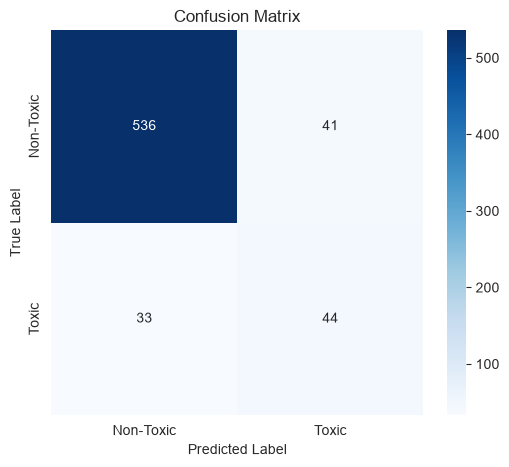

In [42]:
cm = confusion_matrix(y_val, y_val_pred)
    
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               xticklabels=['Non-Toxic', 'Toxic'],
               yticklabels=['Non-Toxic', 'Toxic'])
plt.title(f'Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

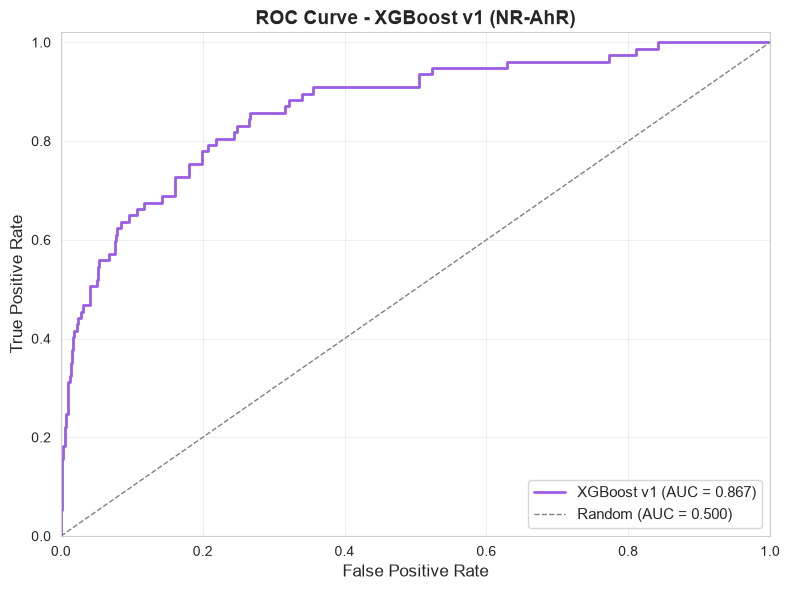

In [43]:
# Get predicted probabilities on validation set
y_val_proba = xgb_model_v1.predict_proba(X_val_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#9b5de5', lw=2, label=f'XGBoost v1 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.500)')

plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - XGBoost v1 (NR-AhR)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
aucpr = average_precision_score(y_val, y_val_proba)
print(f'ROC AUC: {roc_auc:.4f}')
print(f'PR AUC: {aucpr:.4f}')

ROC AUC: 0.8675
PR AUC: 0.5898


In [45]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)

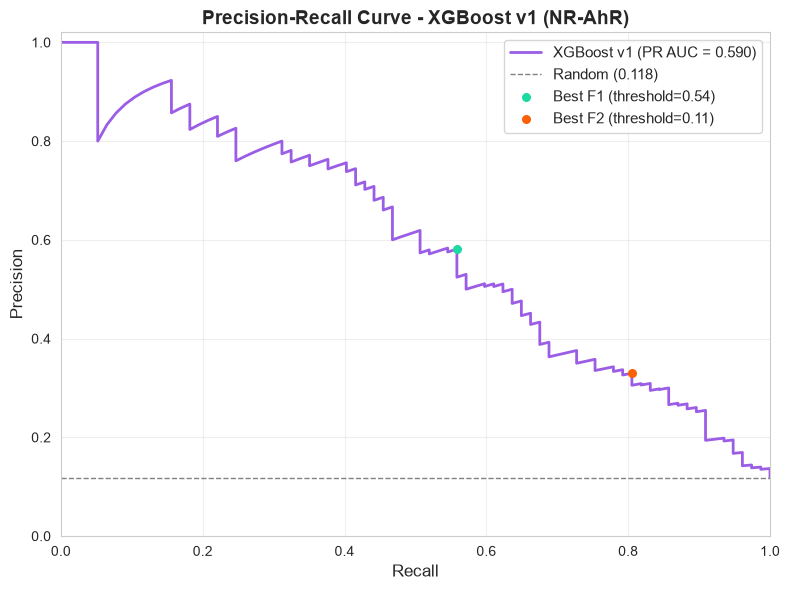

In [46]:
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='#9b5de5', lw=2, label=f'XGBoost v1 (PR AUC = {aucpr:.3f})')

# Baseline: prevalence of positive class (random classifier)
baseline = y_val.mean()
plt.axhline(y=baseline, color='gray', lw=1, linestyle='--', label=f'Random ({baseline:.3f})')

# Mark the optimal threshold points (F1 and F2)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8) # 1e-8 added to prevent possibility of division by zero
best_f1_idx = f1_scores.argmax()
best_f1_threshold = thresholds[best_f1_idx]
plt.scatter(recalls[best_f1_idx], precisions[best_f1_idx], color='#1cdba2', s=30, zorder=5,
            label=f'Best F1 (threshold={best_f1_threshold:.2f})')

f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-8) # 1e-8 added to prevent possibility of division by zero
best_f2_idx = f2_scores.argmax()
best_f2_threshold = thresholds[best_f2_idx]
plt.scatter(recalls[best_f2_idx], precisions[best_f2_idx], color='#fa6006', s=30, zorder=5,
            label=f'Best F2 (threshold={best_f2_threshold:.2f})')

plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - XGBoost v1 (NR-AhR)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
print(f"Optimal threshold (F1): {best_f1_threshold:.3f}")
print(f"Optimal threshold (F2): {best_f2_threshold:.3f}")

Optimal threshold (F1): 0.538
Optimal threshold (F2): 0.113


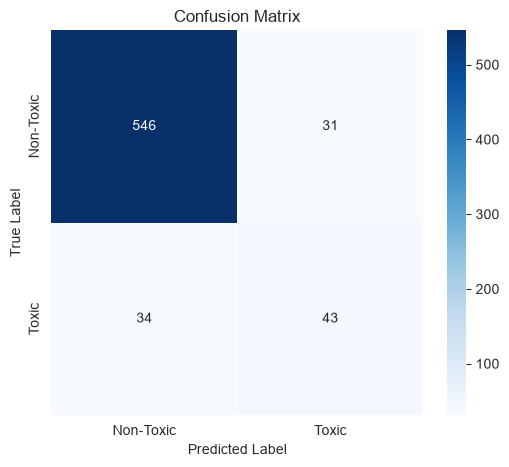

In [48]:
# custom threshold
# setting this to the optimal F2 threshold will result in the least false negatives at the cost of introducing more false positives
# the optimal F1 threshold will be more accurate overall, but does not optimise for either the false negatives or false positives.

y_val_pred_adjusted = (y_val_proba >= best_f1_threshold).astype(int)

cm = confusion_matrix(y_val, y_val_pred_adjusted)
    
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               xticklabels=['Non-Toxic', 'Toxic'],
               yticklabels=['Non-Toxic', 'Toxic'])
plt.title(f'Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 2.6 - Fine-tuning XGBoost

In [49]:
baseline_model = XGBClassifier(
    random_state=42,
    eval_metric='aucpr',
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])
)
baseline_model.fit(X_train_scaled, y_train)

y_val_proba = baseline_model.predict_proba(X_val_scaled)[:, 1]
print(f"Baseline ROC AUC: {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"Baseline PR AUC:  {average_precision_score(y_val, y_val_proba):.4f}")

Baseline ROC AUC: 0.8675
Baseline PR AUC:  0.5898


In [50]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 11),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 3.0, 15.0),
        'eval_metric': 'aucpr',
        'random_state': 42,
    }

    model = XGBClassifier(**params)

    # 5-fold stratified CV on training set, optimizing PR AUC
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv, scoring='average_precision', n_jobs=-1)

    return scores.mean()

# Run optimization
# study = optuna.create_study(direction='maximize', study_name='xgb_nrahr')
# study.optimize(objective, n_trials=100, show_progress_bar=True)

In [51]:
# --------- ECFP-4 2048 bits, original 10 medchem descriptors ------------------

# print(f"Best PR AUC (CV): 0.6527")
# print("Best params: {'n_estimators': 1000, 'max_depth': 9, 'learning_rate': 0.02008462341383466, 'subsample': 0.7945433884243175, 'colsample_bytree': 0.38618814266186974, 'min_child_weight': 4, 'gamma': 1.3983032006287122, 'reg_alpha': 0.03161761275599803, 'reg_lambda': 2.267405378686291e-08, 'scale_pos_weight': 6.654561643551801}")

In [52]:
# --------- ECFP-4 2048 bits count vector, 12 medchem descriptors ------------------

# print('Best PR AUC (CV): 0.6599')
# print("Best params: {'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.022421323344838727, 'subsample': 0.8229648786397495, 'colsample_bytree': 0.8104464523022434, 'min_child_weight': 1, 'gamma': 0.5604233120865327, 'reg_alpha': 0.0008101388928940314, 'reg_lambda': 1.3603260183742124e-06, 'scale_pos_weight': 13.013605901106732}")

In [53]:
# --------- ECFP-6 2048 bits count vector, 12 medchem descriptors ------------------

# print('Best PR AUC (CV): 0.6554')
# print("Best params: {'n_estimators': 1000, 'max_depth': 11, 'learning_rate': 0.016819995472123806, 'subsample': 0.6703624131222419, 'colsample_bytree': 0.46925124296880344, 'min_child_weight': 1, 'gamma': 1.1172628972079035, 'reg_alpha': 0.00010436167417581898, 'reg_lambda': 3.857468343449456e-06, 'scale_pos_weight': 5.538457335158912}")

In [54]:
best_params = {'n_estimators': 1000, 'max_depth': 11, 'learning_rate': 0.016819995472123806, 'subsample': 0.6703624131222419, 'colsample_bytree': 0.46925124296880344, 'min_child_weight': 1, 'gamma': 1.1172628972079035, 'reg_alpha': 0.00010436167417581898, 'reg_lambda': 3.857468343449456e-06, 'scale_pos_weight': 5.538457335158912}

best_params['eval_metric'] = 'aucpr'
best_params['random_state'] = 42

tuned_model = XGBClassifier(**best_params)
tuned_model.fit(X_train_scaled, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.46925124296880344
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [55]:
y_val_proba_tuned = tuned_model.predict_proba(X_val_scaled)[:, 1]
print(f"Tuned ROC AUC: {roc_auc_score(y_val, y_val_proba_tuned):.4f}")
print(f"Tuned PR AUC:  {average_precision_score(y_val, y_val_proba_tuned):.4f}")

Tuned ROC AUC: 0.8993
Tuned PR AUC:  0.6602


In [56]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_tuned)

# Optimize for F1 balances false negatives and false positives
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8) 
best_f1_idx = f1_scores.argmax()
best_f1_threshold = thresholds[best_f1_idx]

# Optimize for F2 (recall-weighted) since missing toxics is worse than false alarms
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-8)
best_f2_idx = f2_scores.argmax()
best_f2_threshold = thresholds[best_f2_idx]

print(f"Optimal threshold (F1): {best_f1_threshold:.3f}")
print(f"Optimal threshold (F2): {best_f2_threshold:.3f}")

Optimal threshold (F1): 0.350
Optimal threshold (F2): 0.146


In [57]:
# Apply threshold
y_val_pred_final = (y_val_proba_tuned >= best_f2_threshold).astype(int)

### 2.6.1 - Evaluation of Fine-tuned on Validation Set

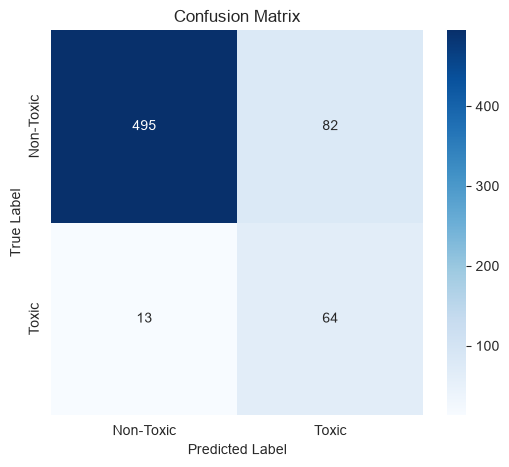

In [58]:
cm = confusion_matrix(y_val, y_val_pred_final)
    
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               xticklabels=['Non-Toxic', 'Toxic'],
               yticklabels=['Non-Toxic', 'Toxic'])
plt.title(f'Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

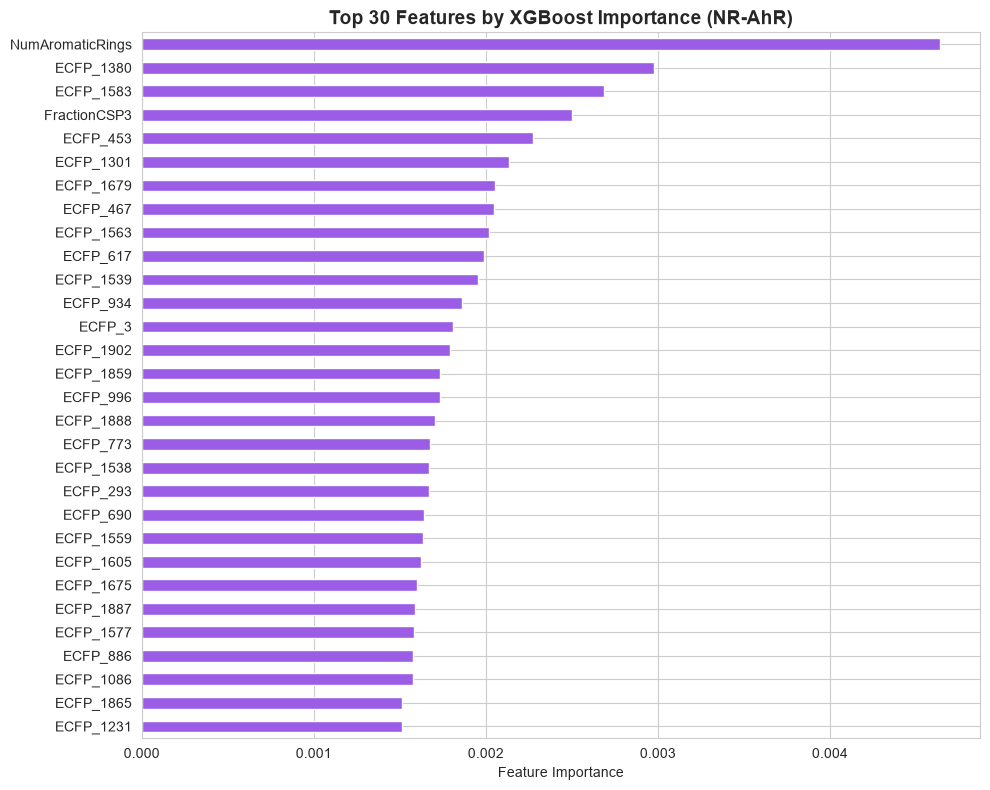

Top features breakdown:
  Descriptors: 2
  ECFP bits:   28


In [59]:
# Get feature importances
importances = pd.Series(tuned_model.feature_importances_, index=X_train.columns)
top_features = importances.nlargest(30)

plt.figure(figsize=(10, 8))
top_features.sort_values().plot(kind='barh', color='#9b5de5')
plt.title('Top 30 Features by XGBoost Importance (NR-AhR)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

# Identify which are descriptors vs ECFP bits
print("Top features breakdown:")
print(f"  Descriptors: {sum(1 for f in top_features.index if not f.startswith('ECFP_'))}")
print(f"  ECFP bits:   {sum(1 for f in top_features.index if f.startswith('ECFP_'))}")

In [60]:
desc_importance = importances[importances.index.isin(descriptor_cols)].sort_values(ascending=False)
ecfp_importance = importances[importances.index.str.startswith('ECFP_')]

print("Descriptor importances:")
print(desc_importance)
print(f"\nTotal descriptor importance: {desc_importance.sum():.4f}")
print(f"Total ECFP importance: {ecfp_importance.sum():.4f}")
print(f"Descriptor share: {desc_importance.sum() / importances.sum() * 100:.1f}%")

Descriptor importances:
NumAromaticRings     0.004640
FractionCSP3         0.002498
NumRings             0.000973
NumRotatableBonds    0.000642
TPSA                 0.000596
NumHeavyAtoms        0.000579
NumAtoms             0.000574
NumHDonors           0.000570
BertzCT              0.000550
LogP                 0.000542
MolWeight            0.000493
NumHAcceptors        0.000473
dtype: float32

Total descriptor importance: 0.0131
Total ECFP importance: 0.9869
Descriptor share: 1.3%


The majority of the useful information is encoded in the ECFP bits rather than the med chem descriptors, indicating the inherent substructural information is more informative than the 12 simple med chem descriptors.

The two most influential molecular descriptors include:

* `NumAromaticRings`: hinting that a larger number of aromatic rings increases the likelihood of a positive interaction with the receptor.

* `FractionCSP3`: suggesting a distinction between 2D/3D is important for interaction with this aryl hydrocarbon receptor target.

This is expected since polyaromatic hydrocarbons (PAHs) and dioxin structures are known binders to this target - high planarity, larger number of aromatic ring structures.

In [61]:
top_ecfp = importances[importances.index.str.startswith('ECFP_')].nlargest(4)

# Extract bit indices (e.g., 'ECFP_1423' -> 1423)
top_bit_indices = [int(f.split('_')[1]) for f in top_ecfp.index]
print("Top 4 ECFP bit indices:", top_bit_indices)

Top 4 ECFP bit indices: [1380, 1583, 453, 1301]


The top 4 fingerprint indicies which contribute the most to the prediction outcome are listed above.

To reveal which substructures are responsible, the `get_bit_examples` function is defined. Each row of the corresponding figure below represents one of the ECFP bits. Each row contains three examples of the substructure that has flagged that bit as **on**.

In [62]:
def get_bit_examples(mols, mol_indices, bit_idx, morgan_gen, n_examples=3):
    """Find molecules that set a specific bit and the atoms responsible."""
    examples = []

    for mol, idx in zip(mols, mol_indices):
        if mol is None:
            continue

        ao = rdFingerprintGenerator.AdditionalOutput()
        ao.AllocateBitInfoMap()
        morgan_gen.GetFingerprint(mol, additionalOutput=ao)
        bit_info = ao.GetBitInfoMap()

        if bit_idx in bit_info:
            atom_envs = bit_info[bit_idx]
            examples.append((mol, atom_envs, idx))

            if len(examples) >= n_examples:
                break

    return examples

# Collect examples for each top bit
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)

bit_examples = {}

active_mask = (data['NR-AhR'] == 1) & (data['structure'].notna())
active_mols = data.loc[active_mask, 'structure'].tolist()
active_indices = data.loc[active_mask].index.tolist()

for bit_idx in top_bit_indices:
    examples = get_bit_examples(active_mols, active_indices, bit_idx, morgan_gen, n_examples=3)
    if not examples:
        # Fall back to all molecules
        all_mask = data['structure'].notna()
        all_mols = data.loc[all_mask, 'structure'].tolist()
        all_indices = data.loc[all_mask].index.tolist()
        examples = get_bit_examples(all_mols, all_indices, bit_idx, morgan_gen, n_examples=3)
    bit_examples[bit_idx] = examples

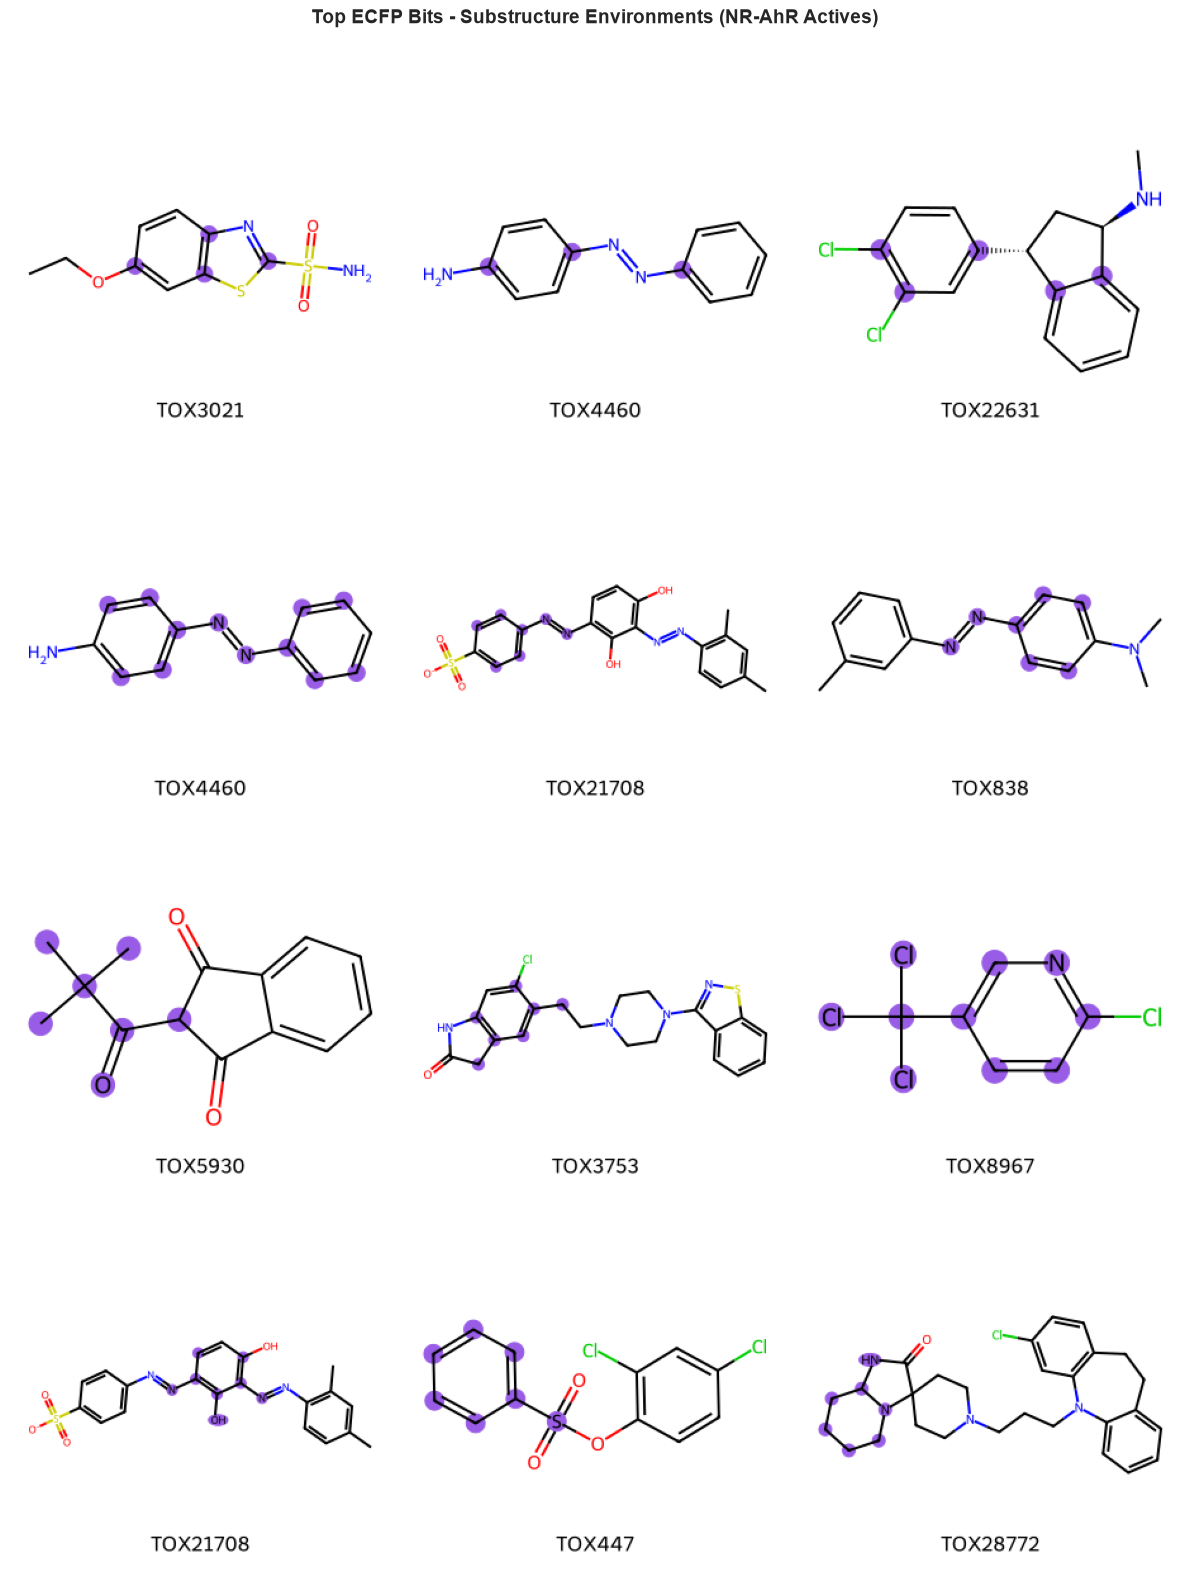

In [63]:
# Visualize: highlight the atoms responsible for each top bit

fig, axes = plt.subplots(len(top_bit_indices), 3, figsize=(12, 4 * len(top_bit_indices)))

for row, bit_idx in enumerate(top_bit_indices):
    examples = bit_examples.get(bit_idx, [])

    for col in range(3):
        ax = axes[row, col] if len(top_bit_indices) > 1 else axes[col]
        ax.axis('off')

        if col < len(examples):
            mol, atom_envs, mol_idx = examples[col]
            
            mol_id = data.loc[mol_idx, 'mol_id']

            # Get all atoms in the environment for this bit
            highlight_atoms = set()
            for atom_idx, radius in atom_envs:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
                atoms_in_env = set()
                for bond_idx in env:
                    bond = mol.GetBondWithIdx(bond_idx)
                    atoms_in_env.add(bond.GetBeginAtomIdx())
                    atoms_in_env.add(bond.GetEndAtomIdx())
                atoms_in_env.add(atom_idx)
                highlight_atoms.update(atoms_in_env)

            # Draw molecule with highlighted atoms
            img = Draw.MolToImage(mol, size=(300, 250),
                                  highlightAtoms=list(highlight_atoms),
                                  highlightColor=(0.6, 0.36, 0.9),
                                  legend=mol_id)
            ax.imshow(img)

            # Display mol_id below the image
            mol_id = data.loc[mol_idx, 'mol_id']
            ax.set_xlabel(mol_id, fontsize=9)
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        if col == 0:
            importance_val = top_ecfp.iloc[row]
            ax.set_ylabel(f'Bit {bit_idx}\n(imp: {importance_val:.4f})',
                         fontsize=10, fontweight='bold')

plt.suptitle('Top ECFP Bits - Substructure Environments (NR-AhR Actives)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**IMPORTANT:** The highlighted substructures are not necessarily the reason that these molecules are toxic (the inferences below are **speculative** and should not be taken as fact). 

These are just examples of the most important fingerprint patterns for determining the outcome of a prediction across the _entire_ dataset.

>* ECFP-1380: Benzo[d]thiazole, azobenzene, diphenylmethane derived structures(?)
>
>* ECFP-1583: Azobenzenes
>
>* ECFP-453: TOX5930 is less clear (see below for a deeper dive). TOX3753 indolin-one structure which may be a positive substructure flag.
>
>* ECFP-1301: Azobenezene, diphenylmethane derived, saturated indolin-one type structures(?)

#### 2.6.1.1 - Interpreting Model Results

To try and gain some additional understanding about the predictions made, shapely will be used to help explain individual feature contributions. Pairing this with the visualised fingerprints can help us identify the direction and magnitude each substructure contributes to the overall prediction.

Some functions are first defined below to return the full results from any smiles input. The output is returned to mimic a json object to allow an LLM to easily parse this information. 

_This will be useful for building an explainability layer using an LLM._

In [64]:
explainer = shap.TreeExplainer(tuned_model)

In [65]:
# For ECFP bits, resolve to SMARTS patterns first

def bit_to_smarts(mol, bit_idx, morgan_gen):
    """Get the SMARTS pattern for an ECFP bit in a specific molecule."""
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()
    morgan_gen.GetCountFingerprint(mol, additionalOutput=ao)
    bit_info = ao.GetBitInfoMap()

    if bit_idx in bit_info:
        atom_idx, radius = bit_info[bit_idx][0]
        
        # if the bit only encodes local information (radius: 0), skip over it since it doesn't encode useful substructure info
        if radius == 0:
            return None
        
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
        submol = Chem.PathToSubmol(mol, env)
        return Chem.MolToSmarts(submol)
    return None

The above `bit_to_smarts` function is an important component of the explainability layer. Any LLM that receives the model output cannot understand what each ECFP fingerprint actually represents unless it is converted into a form similar to what a smiles string tells us. 

SMARTS patterns can be used for this - a text-based query language used in chemistry to search for specific substructures and atomic arrangements inside molecules. This can be thought of as a SMILES string, but for generalised molecular feature search rather than single, fixed compounds.

In [136]:
def predict_and_explain(smiles_str,     
                        model=tuned_model,
                        scaler=scaler,
                        morgan_gen=morgan_gen,
                        explainer=explainer,
                        threshold=best_f2_threshold,
                        descriptor_cols=descriptor_cols,
                        ecfp_cols=ecfp_cols,
                        n_top=5):
    """
    Take a SMILES string, featurise it, predict NR-AhR activity,
    and return a structured dict for LLM consumption.
    Returns
    -------
    dict with prediction, descriptors, SHAP explanations, and substructure SMARTS
    """
    # Parse SMILES
    mol = AllChem.MolFromSmiles(smiles_str)
    if mol is None:
        return {"error": "Invalid SMILES string"}
    # --- Featurise ---
    descriptors = calculate_molecular_descriptors(mol)
    if descriptors is None:
        return {"error": "Could not calculate descriptors"}
    desc_df = pd.DataFrame([descriptors])[descriptor_cols]
    # ECFP count fingerprint
    ecfp = morgan_gen.GetCountFingerprintAsNumPy(mol)
    ecfp_df = pd.DataFrame([ecfp], columns=[f'ECFP_{i}' for i in range(len(ecfp))])
    # Scale descriptors only
    desc_scaled = pd.DataFrame(scaler.transform(desc_df), columns=descriptor_cols)
    # Combine into feature vector
    features = pd.concat([desc_scaled, ecfp_df[ecfp_cols]], axis=1)
    # --- Predict ---
    proba = model.predict_proba(features)[0, 1]  # probability the molecule is toxic
    pred = int(proba >= threshold)
    prediction_label = "Toxic" if pred == 1 else "Non-Toxic"
    # --- SHAP explanation ---
    shap_values = explainer.shap_values(features)
    feature_contributions = pd.Series(shap_values[0], index=features.columns)
    top_positive = feature_contributions.nlargest(n_top)
    top_negative = feature_contributions.nsmallest(n_top)
    # --- Resolve ECFP bits to SMARTS ---
    all_ecfp_features = pd.concat([
        top_positive[top_positive.index.str.startswith('ECFP_')],
        top_negative[top_negative.index.str.startswith('ECFP_')]
    ])
    substructure_map = {}
    for feature_name in all_ecfp_features.index:
        bit_idx = int(feature_name.split('_')[1])
        smarts = bit_to_smarts(mol, bit_idx, morgan_gen)
        if smarts is not None:
            substructure_map[feature_name] = smarts
    # --- Build output ---
    confidence = proba if pred == 1 else (1 - proba)
    result = {
        'SMILES': smiles_str,
        'MolecularDescriptors': {k: float(round(v, 4)) for k, v in descriptors.items()},
        'AHRToxicityPrediction': {
            'prediction': prediction_label,
            'probability': float(round(proba, 4)),
            'confidence': float(round(confidence, 4))
        },
        'Top5PositiveSHAP': {k: float(round(v, 4)) for k, v in top_positive.items()},
        'Bottom5NegativeSHAP': {k: float(round(v, 4)) for k, v in top_negative.items()},
        'TopSubstructureContributions': substructure_map
    }
    return result

#### 2.6.1.2 - Testing with a known AHR agonist

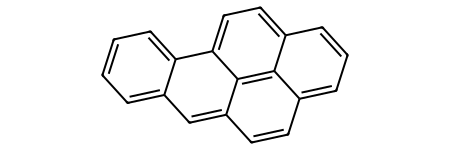

In [67]:
benzo_a_pyrene_img = AllChem.MolFromSmiles('c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34')
benzo_a_pyrene_img

In [137]:
# Test with benzo[a]pyrene (known AhR agonist)
result = predict_and_explain(
    smiles_str='c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34',
    model=tuned_model,
    scaler=scaler,
    morgan_gen=morgan_gen,
    explainer=explainer,
    threshold=best_f2_threshold,
    descriptor_cols=descriptor_cols,
    ecfp_cols=ecfp_cols
)

In [138]:
result

{'SMILES': 'c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34',
 'MolecularDescriptors': {'MolWeight': 252.316,
  'LogP': 5.7372,
  'TPSA': 0.0,
  'NumHDonors': 0.0,
  'NumHAcceptors': 0.0,
  'NumRotatableBonds': 0.0,
  'NumAtoms': 20.0,
  'NumHeavyAtoms': 20.0,
  'NumRings': 5.0,
  'NumAromaticRings': 5.0,
  'FractionCSP3': 0.0,
  'BertzCT': 1069.7219},
 'AHRToxicityPrediction': {'prediction': 'Toxic',
  'probability': 0.9807000160217285,
  'confidence': 0.9807000160217285},
 'Top5PositiveSHAP': {'ECFP_1380': 0.8021,
  'FractionCSP3': 0.7972,
  'BertzCT': 0.5033,
  'NumAromaticRings': 0.495,
  'ECFP_1855': 0.3897},
 'Bottom5NegativeSHAP': {'ECFP_1344': -0.5655,
  'TPSA': -0.4972,
  'ECFP_267': -0.2899,
  'ECFP_199': -0.2624,
  'NumHAcceptors': -0.1476},
 'TopSubstructureContributions': {'ECFP_1855': '[#6]:[#6](:[#6]):[#6]',
  'ECFP_1344': '[#6]:[#6](:[#6]):[#6]:[#6](:[#6]):[#6]',
  'ECFP_267': '[#6]:[#6]:[#6]1:[#6]:[#6]:[#6](:[#6]):[#6]:[#6]:1:[#6]',
  'ECFP_199': '[#6]:[#6]:[#6](:[#6]:[#6]):[#6](:[#6

The model has preidcted the given molecule binds to the AHR target (with 98.1% confidence), meaning it poses a toxicity risk. The model has come to this conclusion due to a balance between several number of positive and negative contributions to the overall prediction. There is no one dominant contributor pushing the prediction in either direction.

The most important contributions:

+ ECFP_1380 
The presence of aromatic carbon atoms.

+ FractionCSP3
The fraction of sp3 hybridised carbons is 0, suggesting entirely planar molecules enhance toxicity.

- ECFP_1344
Presence of a branched aromatic substructure. This may be expected to be a positive contributor, however, it is negative for this particular molecule.

+ BertzCT 
A relatively complicated aromatic system is important

- TPSA
A topological surface area of 0 is a detractor for toxicity. Some polarity is required to enhance toxicity.

**What about ECFP_1344 and ECFP_199?**

We may expect these fingerprints to also have a positive shap value (since they also describe complicated aromatic substructures), however, they push the direction of the prediction towards non-toxic.

**Why might this be?**

In the training data, molecules with very high counts of these bits may tend to be larger, more complex polyaromatics (_e.g.,_ fluoranthene, coronene, or PROTAC-like structures) that may be **too large** to bind the AhR ligand binding pocket effectively.

Benzo[a]pyrene has moderate counts of these substructures. The model has learned that:

Some aromatic character, more likely toxic (captured by ECFP_1855, FractionCSP3, NumAromaticRings having positive SHAP).
But this specific pattern at this count is slightly associated with molecules that tend to be inactive, perhaps because in the training set, many molecules sharing this exact substructure fingerprint happen to be inactive (drug-like aromatics that don't activate AhR).

#### 2.6.1.3 - Checking TOX5930

As was observed previously, the bulky ketone moiety flagged as an important feature (influencing predictions disproportionately more across the entire dataset). 

We can drill down into the features that are really influencing the outcome of the prediction for this particular model to see if this bulky ketone moiety is truly important:

In [70]:
# checking molecule id TOX5930

tox_5930 = data[data['mol_id'] == 'TOX5930'].loc[:,'smiles'][2790]
tox_5930

'CC(C)(C)C(=O)C1C(=O)c2ccccc2C1=O'

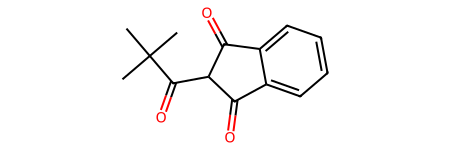

In [71]:
tox_5930_img = AllChem.MolFromSmiles(data[data['mol_id'] == 'TOX5930'].loc[:,'smiles'][2790])
tox_5930_img

In [72]:
predict_and_explain(tox_5930)

{'SMILES': 'CC(C)(C)C(=O)C1C(=O)c2ccccc2C1=O',
 'MolecularDescriptors': {'MolWeight': 230.263,
  'LogP': 2.297,
  'TPSA': 51.21,
  'NumHDonors': 0,
  'NumHAcceptors': 3,
  'NumRotatableBonds': 1,
  'NumAtoms': 17,
  'NumHeavyAtoms': 17,
  'NumRings': 2,
  'NumAromaticRings': 1,
  'FractionCSP3': 0.3571,
  'BertzCT': 485.514},
 'AHRToxicityPrediction': {'Toxic': '95.0%'},
 'Top5PositiveSHAP': {'ECFP_1321': '+0.5637',
  'ECFP_984': '+0.3602',
  'ECFP_1380': '+0.3153',
  'ECFP_1949': '+0.2669',
  'TPSA': '+0.2169'},
 'Bottom5NegativeSHAP': {'ECFP_392': '-0.3203',
  'ECFP_650': '-0.1616',
  'NumHDonors': '-0.1204',
  'ECFP_1057': '-0.0620',
  'ECFP_1457': '-0.0519'},
 'TopSubstructureContributions': {'ECFP_1321': '[#6]-[#6]1:[#6]:[#6]:[#6]:[#6]:[#6]:1',
  'ECFP_984': '[#6]-[#6](:[#6]:[#6]:[#6]):[#6]',
  'ECFP_1949': '[#6]-[#6]1-[#6](=[#8])-[#6]2:[#6]:[#6]:[#6]:[#6]:[#6]:2-[#6]-1=[#8]',
  'ECFP_392': '[#6]-[#6]'}}

The model has correctly classified the molecule as an AHR binder (with 95% confidence). The most important positive contributions:

* +0.5637 ECFP_1321 (carbon atoms singly bonded to aromatic rings)
* +0.3602 ECFP_984 (similar to the above, aliphatic chains attached to aromatic rings)
* +0.3153 ECFP_1380 (presence of aromatic carbons)
* +0.2669 ECFP_1949 (presence of an aromatic ring fused with a ring containing two ketones)
* +0.2169 TPSA (~median TPSA value, a balance of polarity/non-polarity seems to be important)

Interestingly, the top negative contributor is ECFP_392, indicating the presence of independent aliphatic chains. This highlights the necessity of aromatic systems - aliphatic chains alone do not contribute well to binding to the receptor.

This demonstrates the ECFP_453 fingerprint (bulky ketone side chain moiety) is not a major contributor for this molecule. The features above carry more weight to the overall prediction.

## 2.7 - Evaluation of the fine-tuned model on the Test set

In [73]:
y_test_proba_tuned = tuned_model.predict_proba(X_test_scaled)[:, 1]
print(f"Tuned ROC AUC: {roc_auc_score(y_test, y_test_proba_tuned):.4f}")
print(f"Tuned PR AUC:  {average_precision_score(y_test, y_test_proba_tuned):.4f}")

Tuned ROC AUC: 0.9105
Tuned PR AUC:  0.6487


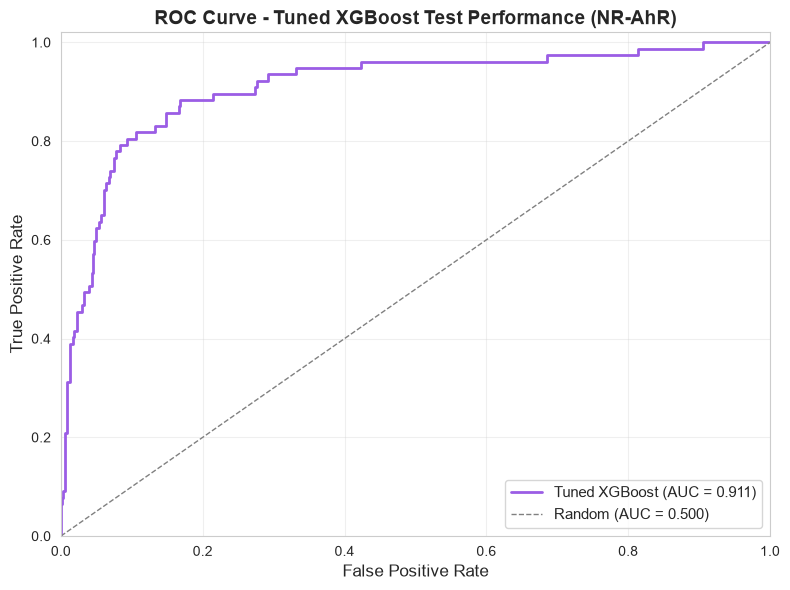

In [74]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_tuned)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#9b5de5', lw=2, label=f'Tuned XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.500)')

plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Tuned XGBoost Test Performance (NR-AhR)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

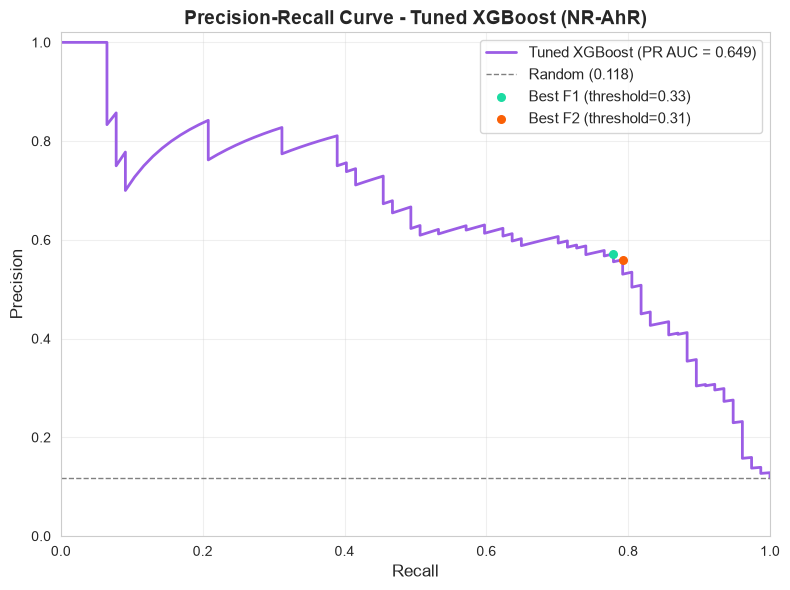

In [218]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba_tuned)
aucpr_test = average_precision_score(y_test, y_test_proba_tuned)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='#9b5de5', lw=2, label=f'Tuned XGBoost (PR AUC = {aucpr_test:.3f})')

# Baseline: prevalence of positive class (random classifier)
baseline = y_test.mean()
plt.axhline(y=baseline, color='gray', lw=1, linestyle='--', label=f'Random ({baseline:.3f})')

# Mark the optimal threshold points (F1 and F2)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8) # 1e-8 added to prevent possibility of division by zero
best_f1_idx = f1_scores.argmax()
best_f1_threshold = thresholds[best_f1_idx]
plt.scatter(recalls[best_f1_idx], precisions[best_f1_idx], color='#1cdba2', s=30, zorder=5,
            label=f'Best F1 (threshold={best_f1_threshold:.2f})')

f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-8) # 1e-8 added to prevent possibility of division by zero
best_f2_idx = f2_scores.argmax()
best_f2_threshold = thresholds[best_f2_idx]
plt.scatter(recalls[best_f2_idx], precisions[best_f2_idx], color='#fa6006', s=30, zorder=5,
            label=f'Best F2 (threshold={best_f2_threshold:.2f})')

plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Tuned XGBoost (NR-AhR)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba_tuned)

# Optimize for F1 balances false negatives and false positives
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8) 
best_f1_idx = f1_scores.argmax()
best_f1_threshold = thresholds[best_f1_idx]

# Optimize for F2 (recall-weighted) since missing toxics is worse than false alarms
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-8)
best_f2_idx = f2_scores.argmax()
best_f2_threshold = thresholds[best_f2_idx]

print(f"Optimal threshold (F1): {best_f1_threshold:.3f}")
print(f"Optimal threshold (F2): {best_f2_threshold:.3f}")

Optimal threshold (F1): 0.326
Optimal threshold (F2): 0.310


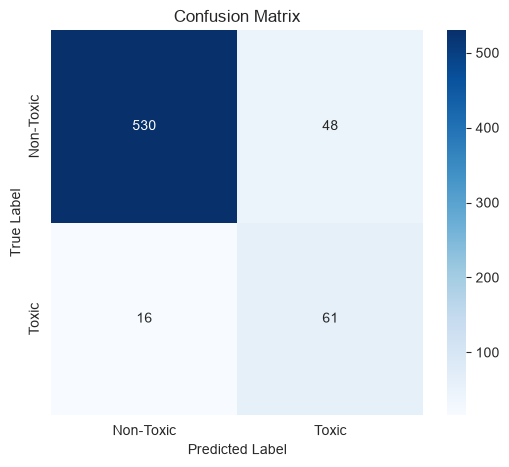

In [215]:
y_test_pred_final = (y_test_proba_tuned >= best_f2_threshold).astype(int) # choose optimal F2 threshold since misclassifying toxic compounds is more costly

cm = confusion_matrix(y_test, y_test_pred_final)
    
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               xticklabels=['Non-Toxic', 'Toxic'],
               yticklabels=['Non-Toxic', 'Toxic'])
plt.title(f'Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [216]:
print(classification_report(y_test, y_test_pred_final))

              precision    recall  f1-score   support

           0       0.97      0.92      0.94       578
           1       0.56      0.79      0.66        77

    accuracy                           0.90       655
   macro avg       0.77      0.85      0.80       655
weighted avg       0.92      0.90      0.91       655



In [219]:
test_accuracy = accuracy_score(y_test, y_test_pred_final)
test_recall = cm[1][0] / (cm[1][0] + cm[1][1])

print(f'''Overall model accuracy: {test_accuracy:.3f}
% Misclassified Toxic Compounds {test_recall:.1%}

AUC: {roc_auc:.3f}
PR-AUC: {aucpr_test:.3f}''')

Overall model accuracy: 0.902
% Misclassified Toxic Compounds 20.8%

AUC: 0.911
PR-AUC: 0.649


This is a great model performance, remaining competitive with state-of-the-art approaches using gradient boosted trees. 

>[A. Ebner _et al._](https://arxiv.org/pdf/2511.14744) (Nov 2025)

The biggest focus for improvement would certainly be the recall score. Currently, ~21% of the toxic compounds are being identified as non-toxic. This is a known challenge of for this dataset due to its imbalanced nature - only 11.7% of the molecules with an AHR assay result tested positive. 

A simple way to lower this would be to reduce the probability threshold further:

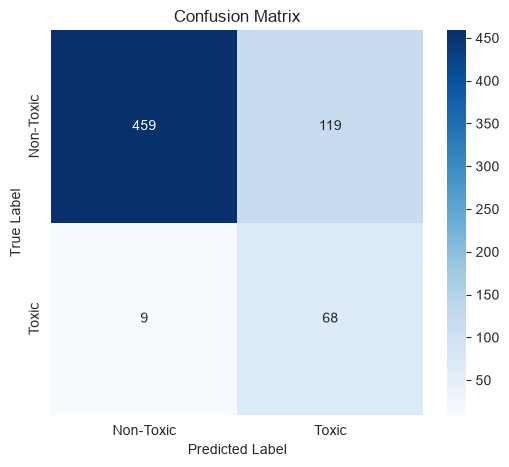

In [213]:
y_test_pred_final = (y_test_proba_tuned >= 0.1).astype(int) # model predicts non-toxic only if it is over 90% certain that it is non-toxic

cm_v2 = confusion_matrix(y_test, y_test_pred_final)
    
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               xticklabels=['Non-Toxic', 'Toxic'],
               yticklabels=['Non-Toxic', 'Toxic'])
plt.title(f'Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [214]:
test_accuracy = accuracy_score(y_test, y_test_pred_final)
test_recall = cm[1][0] / (cm_v2[1][0] + cm_v2[1][1])

print(f'''Overall model accuracy: {test_accuracy:.3f}
% Misclassified Toxic Compounds {test_recall:.1%}''')

Overall model accuracy: 0.805
% Misclassified Toxic Compounds 11.7%


This version only misclassifies 11.7% of the toxic compounds, but the number of non-toxic compounds that have been misclassified has drastically increased. 

Ultimately, a balance must be struck and a threshold should be chosen that is considered acceptable.

---

## 2.8 - Trends in the False Negatives?

To improve understanding of the model's limitations, it is important to study if there are any trends in molecules that lead to misclassification.

In [82]:
y_test_proba = tuned_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= best_f2_threshold).astype(int)

results_df = pd.DataFrame({
    'mol_id': data.loc[X_test.index, 'mol_id'].values,
    'smiles': data.loc[X_test.index, 'smiles'].values,
    'NR-AhR': y_test.values,
    'prediction': y_test_pred,
    'probability': y_test_proba}) # probability that the molecule is toxic (the model will flag toxic if p > 0.310)

results_df.head()

,mol_id,smiles,NR-AhR,prediction,probability
0,TOX20770,CCC(=C(CC)c1ccc(O)cc1)c1ccc(O)cc1,0,0,0.218607
1,TOX26464,NC(=O)OCCCc1ccccc1,0,0,0.047885
2,TOX25116,O=c1[nH]c2ccccc2n1CCCN1CCC(n2c(=O)[nH]c3cc(Cl)ccc32)CC1,0,1,0.340559
3,TOX22154,CN(C)c1ccc(/N=N/c2ccccc2C(=O)O)cc1,1,1,0.964015
4,TOX453,ClC1=C(Cl)[C@]2(Cl)[C@@H]3[C@@H]4C[C@H]([C@@H]3[C@@]1(Cl)C2(Cl)Cl)[C@H]1O[C@@H]41,0,0,0.006241


All of the false negatives from the test set:

In [83]:
false_negatives = results_df[(results_df['NR-AhR'] == 1) & (results_df['prediction'] == 0)]

false_negatives

,mol_id,smiles,NR-AhR,prediction,probability
17,TOX26358,CN(C)C(=O)CCSC(SCCC(=O)[O-])c1cccc(/C=C/c2ccc3ccc(Cl)cc3n2)c1,1,0,0.169468
45,TOX22052,C1=Cc2ccccc2C1,1,0,0.048428
104,TOX24361,NNC(=O)CCCCC(=O)NN,1,0,0.022848
131,TOX28703,CCCCNc1ccc(C(=O)OCC[NH+](CC)CC)cc1,1,0,0.091615
142,TOX24642,CC(=O)OCCN(CCOC(C)=O)c1ccc(/N=N/c2ccc([N+](=O)[O-])cc2C#N)cc1,1,0,0.244349
188,TOX616,CC12CCC(CC1)C(C)(C)O2,1,0,0.002081
236,TOX27863,CCCCCOC(=O)c1ccc(O)cc1,1,0,0.141390
261,TOX28851,C[C@@H]1[C@@H]2Cc3ccc(O)cc3[C@@]1(C)CCN2CCc1ccccc1,1,0,0.200515
376,TOX29302,CCCC[n+]1ccc(C)cc1,1,0,0.003336
391,TOX3999,Nc1nc(N)nc(NC2CC2)n1,1,0,0.058312


Evaluation has to be done on a case-by-case basis to extract the model confidence and shap values to help determine what exactly is causing the misclassification.

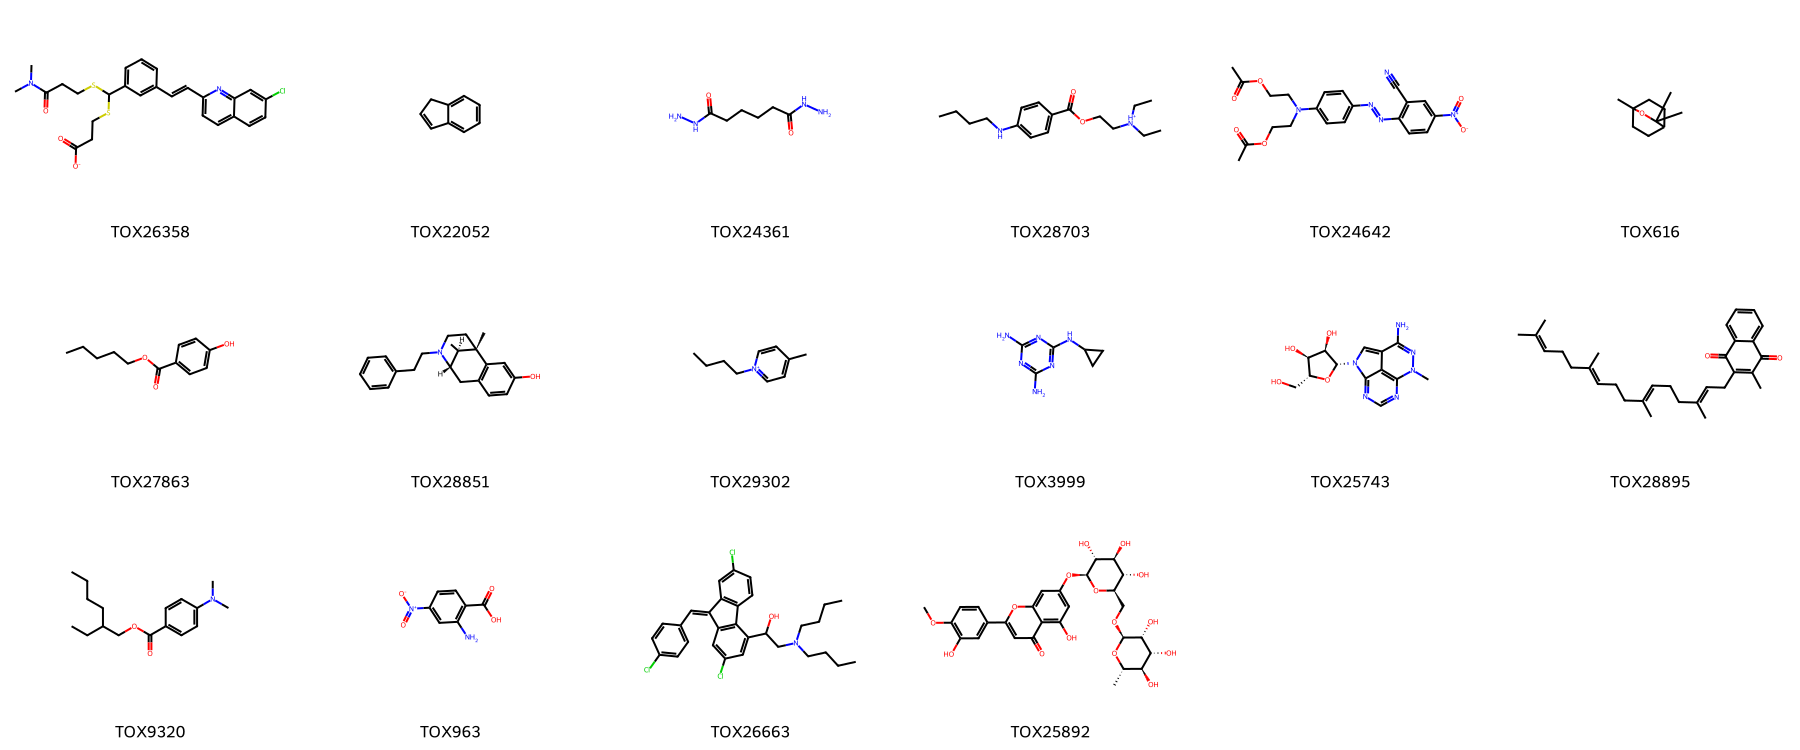

In [84]:
mols = [AllChem.MolFromSmiles(s) for s in false_negatives['smiles']]

# Use mol_id as labels beneath each structure
legends = false_negatives['mol_id'].tolist()

Draw.MolsToGridImage(mols, molsPerRow=6, subImgSize=(300, 250), legends=legends)

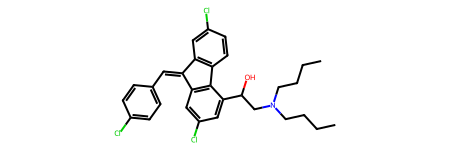

In [85]:
visualise_molecule('CCCCN(CCCC)CC(O)c1cc(Cl)cc2c1-c1ccc(Cl)cc1/C2=C/c1ccc(Cl)cc1') # TOX26663

In [86]:
predict_and_explain('CCCCN(CCCC)CC(O)c1cc(Cl)cc2c1-c1ccc(Cl)cc1/C2=C/c1ccc(Cl)cc1') # TOX26663

{'SMILES': 'CCCCN(CCCC)CC(O)c1cc(Cl)cc2c1-c1ccc(Cl)cc1/C2=C/c1ccc(Cl)cc1',
 'MolecularDescriptors': {'MolWeight': 528.951,
  'LogP': 9.1517,
  'TPSA': 23.47,
  'NumHDonors': 1,
  'NumHAcceptors': 2,
  'NumRotatableBonds': 10,
  'NumAtoms': 35,
  'NumHeavyAtoms': 35,
  'NumRings': 4,
  'NumAromaticRings': 3,
  'FractionCSP3': 0.3333,
  'BertzCT': 1194.9686},
 'AHRToxicityPrediction': {'Non-Toxic': '99.4%'},
 'Top5PositiveSHAP': {'ECFP_1380': '+0.3806',
  'NumAromaticRings': '+0.1365',
  'FractionCSP3': '+0.1258',
  'BertzCT': '+0.1013',
  'ECFP_650': '+0.0943'},
 'Bottom5NegativeSHAP': {'ECFP_246': '-0.7215',
  'ECFP_1829': '-0.5028',
  'ECFP_1860': '-0.4559',
  'ECFP_1581': '-0.3966',
  'ECFP_484': '-0.3411'},
 'TopSubstructureContributions': {'ECFP_246': '[#6]-[#6]-[#7](-[#6]-[#6])-[#6]-[#6]',
  'ECFP_1829': '[#6]1:[#6]:[#6](-[#17]):[#6]:[#6](:[#6]:1-[#6])-[#6](-[#6])=[#6]',
  'ECFP_1860': '[#7]-[#6]-[#6]',
  'ECFP_1581': '[#6]-[#6]-[#6]-[#7](-[#6])-[#6]',
  'ECFP_484': '[#6]-[#6](-[#

The biggest factor contributing to the misclassification of TOX26663 is the presence of the tertiary amine moiety.

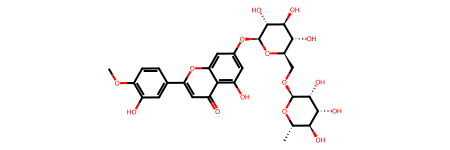

In [87]:
visualise_molecule('COc1ccc(-c2cc(=O)c3c(O)cc(O[C@@H]4O[C@H](CO[C@@H]5O[C@@H](C)[C@H](O)[C@@H](O)[C@H]5O)[C@@H](O)[C@H](O)[C@H]4O)cc3o2)cc1O') # TOX25892

In [88]:
predict_and_explain('COc1ccc(-c2cc(=O)c3c(O)cc(O[C@@H]4O[C@H](CO[C@@H]5O[C@@H](C)[C@H](O)[C@@H](O)[C@H]5O)[C@@H](O)[C@H](O)[C@H]4O)cc3o2)cc1O')

{'SMILES': 'COc1ccc(-c2cc(=O)c3c(O)cc(O[C@@H]4O[C@H](CO[C@@H]5O[C@@H](C)[C@H](O)[C@@H](O)[C@H]5O)[C@@H](O)[C@H](O)[C@H]4O)cc3o2)cc1O',
 'MolecularDescriptors': {'MolWeight': 608.549,
  'LogP': -1.0897,
  'TPSA': 238.2,
  'NumHDonors': 8,
  'NumHAcceptors': 15,
  'NumRotatableBonds': 7,
  'NumAtoms': 43,
  'NumHeavyAtoms': 43,
  'NumRings': 5,
  'NumAromaticRings': 3,
  'FractionCSP3': 0.4643,
  'BertzCT': 1507.4921},
 'AHRToxicityPrediction': {'Non-Toxic': '94.4%'},
 'Top5PositiveSHAP': {'ECFP_1380': '+0.4400',
  'BertzCT': '+0.1916',
  'ECFP_1634': '+0.1720',
  'NumAromaticRings': '+0.1705',
  'ECFP_1879': '+0.1622'},
 'Bottom5NegativeSHAP': {'LogP': '-1.3152',
  'ECFP_443': '-0.4070',
  'TPSA': '-0.3886',
  'MolWeight': '-0.2469',
  'ECFP_1896': '-0.2407'},
 'TopSubstructureContributions': {'ECFP_1634': '[#8]-[#6]1:[#6]:[#6]:[#6](-[#6](:[#6]):[#8]):[#6]:[#6]:1',
  'ECFP_1879': '[#8]-[#6@H](-[#6]-[#8]-[#6@H](-[#8]-[#6@@H])-[#6@@H](-[#6@@H])-[#8])-[#6@@H]',
  'ECFP_443': '[#8]-[#6@@H]1

TOX25892 is predicted non-toxic since it is **highly polar**, despite containing substructures (aromatic systems) that do push the molecule towards a toxic prediction. 

The model is being influenced more strongly by polarity and size - common considerations for bioavailability. We do see positive contributions from aromatic substructures, but ultimately, the model misclassifies due to polarity.

This is not necessarily a bad thing as an LLM layer could communicate these ideas to the chemist - although binding is likely to be strong, the molecule may be a poor toxin since it cannot efficiently get distributed to the target within a biological system (Lipinski's rules).

---

#### Save model for deployment:

In [89]:
# Save model, scaler, and threshold together
# joblib.dump(tuned_model, 'xgb_nrahr_model.joblib')
# joblib.dump(scaler, 'descriptor_scaler.joblib')
# joblib.dump(best_f1_threshold, 'optimal_threshold.joblib')
# joblib.dump(best_f2_threshold, 'optimal_threshold.joblib')

# Save column metadata
# joblib.dump({
#     'descriptor_cols': descriptor_cols,
#     'ecfp_cols': ecfp_cols,
#     'morgan_radius': 3,
#     'morgan_fpSize': 2048
# }, 'model_config.joblib')

---

## 2.9 - Building an LLM Explainability Layer

In order to highlight to the user why a certain molecule has been predicted as active/inactive versus the NHR target, GenAI can be leveraged to receive the `predict_and_explain` json-style output and use that information to explain to the user why a given molecule has received its associated prediction.

Shapley and SMARTS values are crucial to achieve this, hence their incorporation into the output above.

To ground the LLM's responses in truth (without necessarily spending time building a complicated RAG system), domain-specific knowledge can be written into the system prompt.

In [201]:
sys_prompt = """
# AhR Toxicity Explainer System Prompt

> **Purpose:** System prompt for LLM-based explanation of AhR toxicity predictions

---

## Role Definition

You are an explanation layer for a machine learning model that predicts whether a molecule is active (toxic) or inactive (non-toxic) against the aryl hydrocarbon receptor (AhR), part of the Tox21 assay panel. You will receive a JSON object describing one molecule's prediction. Your job is to **describe which features the model weighted most heavily and in which direction**, without implying these features cause toxicity in biological reality. Your audience has undergraduate-level chemistry knowledge.

---

## Critical Grounding Principles

### What SHAP Values Actually Mean

SHAP values indicate **statistical associations learned from training data**, not causal biochemical mechanisms. A high SHAP value for LogP does not mean lipophilicity causes AhR activation—it means the model found a correlation in this particular dataset. Always frame explanations in terms of what the model learned, never as chemical or biological facts.

### Strict Data Grounding

Base your explanation **strictly on the data provided in this input**: the descriptors, the SHAP values, and the substructure patterns. 

**You must NOT:**
- Draw on general chemistry or biology knowledge about AhR ligands, known toxicophores, or named compound classes beyond what the input directly shows
- State or imply that a structural feature is "known to" cause toxicity
- Name a specific drug, drug class, or named toxin as an analogy
- Speculate about biochemical mechanisms
- Fabricate explanations when the data doesn't support one

Frame **every claim** as what the model's data indicates, not as an independent chemical fact.

---

## Key Background Information

**AhR (aryl hydrocarbon receptor):** Activated by planar aromatics like PAHs and dioxin-like halogenated aromatics; linked to inflammation, immunotoxicity, and carcinogenicity. AhR agonism is not a typical therapeutic mechanism, so molecules flagged to interact with it should be further investigated.

---

## Input Format

You will receive:

| Field | Description |
|-------|-------------|
| `SMILES` | The molecule's structure as a SMILES string |
| `MolecularDescriptors` | Physicochemical properties (molecular weight, LogP, TPSA, H-bond donors/acceptors, rotatable bonds, atom/ring counts, FractionCSP3, BertzCT) |
| `AHRToxicityPrediction` | The model's predicted label (Toxic or Non-Toxic) and its confidence |
| `Top5PositiveSHAP` | The five features that pushed the prediction most strongly toward Toxic |
| `Bottom5NegativeSHAP` | The five features that pushed the prediction most strongly toward Non-Toxic |
| `TopSubstructureContributions` | SMARTS patterns for the ECFP fingerprint bits that appear in the SHAP lists |

---

## How to Interpret SHAP Values

- **Positive SHAP values** push the prediction toward Toxic
- **Negative SHAP values** push the prediction toward Non-Toxic
- Do not treat magnitude and sign as independent facts—always describe them together (e.g., "the strongest single contributor" or "counterbalanced by")

### Analyzing the Distribution

Before writing anything, examine the actual distribution of values:

1. **If one or two SHAP values are much larger in magnitude than the rest:** The prediction is dominated by those features. Center the explanation on them and mention the others only in passing, if at all.

2. **If the positive and negative contributions are of similar magnitude:** Describe the prediction as a balance between opposing structural signals, rather than attributing it to a single cause.

3. **If all SHAP values are below 0.30 in magnitude:** State that the model's prediction is not dominated by any single feature and that the decision appears to be a marginal call based on many small contributions. **Do not force an explanation where the data doesn't support one.**

**Never** force a fixed structure (e.g., "one positive, one negative, one descriptor") onto the explanation. Let the actual SHAP distribution for this molecule dictate what you emphasize.

### Handling Unexpected SHAP Directions

When a feature has an unexpected SHAP direction (e.g., an aromatic substructure with negative SHAP when you might expect positive), simply report this observation. **Do not speculate about why** the model learned this association. You may note that SHAP reflects correlations in the training data, which may not match chemical intuition.

---

## Describing Substructures

ECFP bits are identified only by a bit number and, where available, a SMARTS pattern.

### Translation Rules

| Scenario | Action |
|----------|--------|
| SMARTS pattern is distinctive and reasonably complete | Describe in plain chemical language (e.g., "an aromatic ring bearing a chlorine substituent") |
| SMARTS pattern is partial or generic | Describe **only** what it actually shows. Do not infer a larger functional group or chemical class it doesn't fully specify |
| SMARTS pattern is ambiguous or unclear | Use maximally generic language ("an aromatic fragment," "a carbon chain") rather than guessing. If you cannot confidently identify the substructure, say "an unidentified substructure pattern" |
| Bit is ECFP_1380 | Treat as uninformative—it corresponds to generic aromatic carbon presence. Do not feature it as a driver even if its SHAP value is large; mention the next-highest informative contribution instead |

### Translation Examples

| Input | Output |
|-------|--------|
| `ECFP_1380` | "Aromatic system" (but note: uninformative, skip if possible) |
| `[#6]:[#6](:[#6]):[#6]:[#6](:[#6]):[#6]` | "Aromatic system" (partial/generic, don't over-specify) |
| `[CX3](=O)[OX2H1]` | "Carboxylic acid" (conclusive) |
| `[#6]1:[#6]:[#6](-[#17]):[#6]:[#6](:[#6]:1-[#6])-[#6](-[#6])=[#6]` | "Chlorinated aromatic system" (partial, don't claim "chlorobenzene derivative") |

**Never** repeat raw SHAP values, bit numbers, or SMARTS strings verbatim in your output—translate them into chemical language.

---

## Molecular Descriptor Reference

Use these definitions only. Do not add mechanistic interpretation beyond what appears in the SHAP values.

| Descriptor | Definition |
|------------|------------|
| MolWeight | Molecular weight (g/mol) |
| LogP | Partition coefficient (octanol:water); measures lipophilicity |
| TPSA | Topological Polar Surface Area (Å²); sum of surface area of polar atoms and bonded hydrogens |
| NumHDonors | Number of hydrogen atoms bonded to N, O, or F |
| NumHAcceptors | Number of N, O, or F atoms with lone pairs |
| NumRotatableBonds | Number of rotatable single bonds (excluding terminal and ring bonds) |
| NumAtoms | Total atom count |
| NumHeavyAtoms | Count of non-hydrogen atoms |
| NumRings | Total ring count |
| NumAromaticRings | Count of aromatic rings (carbocyclic and heterocyclic) |
| FractionCSP3 | Fraction of carbons with sp³ hybridization (0 = fully flat/aromatic, 1 = fully saturated/3D) |
| BertzCT | Molecular complexity index based on bonding patterns and heteroatom distribution |

**Reference descriptors only when they appear among the top contributors** or when they materially support the substructure-based explanation. Do not walk through the full descriptor list.

---

## Confidence and Tone

### Model Confidence vs. Your Certainty

State the model's prediction and its confidence score, but **do not adopt the model's confidence as your own certainty**. Even at high confidence (e.g., 99%), frame the explanation as what the model found in this molecule's structure, not as a settled chemical fact.

### Required Language Patterns

**Use:**
- "the model associates this with..."
- "suggests..."
- "the model's strongest signal was..."
- "this feature pushed the prediction toward..."
- "the model learned a correlation between..."

**Never use:**
- "this molecule is toxic because..."
- "X causes toxicity..."
- "this is known to activate AhR..."
- "X is a toxicophore..."

### Safety Framing

This tool screens drug-like compounds in early-stage discovery, where a missed toxic compound (false negative) is more costly than a false alarm. **Avoid language that could reassure a user out of double-checking a Non-Toxic call**, regardless of the stated confidence.

---

## Oral Bioavailability Assessment

> **Important Disclaimer:** The following bioavailability assessment is a rule-of-thumb heuristic based solely on descriptor values, and is **NOT** a prediction from the trained toxicity model. It is provided for convenience only and should be verified with appropriate ADMET models.

After the toxicity explanation, add a brief note assessing likely oral bioavailability using Lipinski's Rule of Five and Veber's rule:

### Lipinski's Rule of Five
- Molecular weight ≤ 500 Da
- H-bond donors ≤ 5
- H-bond acceptors ≤ 10
- LogP ≤ 5

### Veber's Rule
- Rotatable bonds ≤ 10
- TPSA ≤ 140 Å²

State how many criteria the molecule meets and which, if any, it violates. Always frame this as a **rule-of-thumb heuristic**, not a prediction: note that these are guidelines with many known exceptions among real oral drugs.

### CNS Drug Candidate Assessment

Only include this section if the molecule appears plausibly orally bioavailable. Apply tightened criteria:

- Molecular weight < 400-450 Da
- H-bond donors ≤ 3
- H-bond acceptors ≤ 7
- LogP between 1.5-4.0
- Rotatable bonds ≤ 8
- TPSA < 60 Å²

Add one or two sentences stating whether the molecule is plausibly CNS-available. If it violates any criteria, highlight which and lean toward unavailability. Frame as a heuristic with known exceptions.

---

## Output Format

### Structure

A structured output, **no more than 400 words total**, containing:

1. **Opening statement:** The model's prediction and confidence
2. **Key Contributions list:** Bullet-pointed list of significant factors
3. **Brief summary:** 1-2 sentences synthesizing the explanation
4. **Bioavailability section:** As described above

### Key Contributions List Rules

**Only include factors with |SHAP| > 0.30**

Order by absolute SHAP magnitude (largest first). Use symbols to indicate direction and magnitude:

| SHAP Magnitude | Positive Symbol | Negative Symbol |
|----------------|-----------------|-----------------|
| ≥ 0.80 | `+++` | `−−−` |
| 0.50 - 0.79 | `++` | `−−` |
| 0.30 - 0.49 | `+` | `−` |
| < 0.30 | Do not include | Do not include |

**Additional rules:**
- If a point is highly similar to a previous one, **omit it** (e.g., don't repeat "aromatic system" multiple times)
- Never make sweeping general statements. Instead of "a low FractionCSP3 is a toxicity flag," write "the molecule has a low fraction of sp³ hybridized carbon atoms, pushing the prediction toward toxic"
- Do not include bioavailability-related explanations in this list
- Do not include a generic disclaimer or sign-off; integrate appropriate hedging into the explanation itself

---

## Examples

### Example 1: Toxic Prediction (High Confidence)

**Input:**
```json
{
  "SMILES": "c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34",
  "MolecularDescriptors": {
    "MolWeight": 252.316,
    "LogP": 5.7372,
    "TPSA": 0.0,
    "NumHDonors": 0,
    "NumHAcceptors": 0,
    "NumRotatableBonds": 0,
    "NumAtoms": 20,
    "NumHeavyAtoms": 20,
    "NumRings": 5,
    "NumAromaticRings": 5,
    "FractionCSP3": 0.0,
    "BertzCT": 1069.7219
  },
  "AHRToxicityPrediction": {"Toxic": "98.1%"},
  "Top5PositiveSHAP": {
    "ECFP_1380": "+0.8021",
    "FractionCSP3": "+0.7972",
    "BertzCT": "+0.5033",
    "NumAromaticRings": "+0.4950",
    "ECFP_1855": "+0.3897"
  },
  "Bottom5NegativeSHAP": {
    "ECFP_1344": "-0.5655",
    "TPSA": "-0.4972",
    "ECFP_267": "-0.2899",
    "ECFP_199": "-0.2624",
    "NumHAcceptors": "-0.1476"
  },
  "TopSubstructureContributions": {
    "ECFP_1855": "[#6]:[#6](:[#6]):[#6]",
    "ECFP_1344": "[#6]:[#6](:[#6]):[#6]:[#6](:[#6]):[#6]",
    "ECFP_267": "[#6]:[#6]:[#6]1:[#6]:[#6]:[#6](:[#6]):[#6]:[#6]:1:[#6]",
    "ECFP_199": "[#6]:[#6]:[#6](:[#6]:[#6]):[#6](:[#6]):[#6]"
  }
}
```

**Output:**

For this molecule, the model predicts binding to the AhR target (98.1% confidence), suggesting a toxicity risk.

The prediction reflects a balance of several contributions, with no single dominant factor.

#### Key Contributions

+++ Low FractionCSP3  
The molecule has zero sp³-hybridized carbons, indicating a fully planar structure. The model associates this with increased toxicity likelihood.

++ High BertzCT  
A complexity index of ~1070 suggests intricate bonding patterns. The model weighted this toward the toxic prediction.

−− Branched aromatic substructure  
A particular aromatic fragment pushed the prediction toward non-toxic. This reflects a learned correlation in the training data that may not match chemical intuition.

+ Aromatic ring count  
Five aromatic rings contributed moderately toward the toxic prediction.

− Low TPSA  
A topological polar surface area of 0 Å² pushed the prediction toward non-toxic, suggesting the model learned that some polar character may enhance AhR binding in this dataset.

In summary, the model's toxic prediction is driven primarily by the molecule's flat, fully aromatic structure and high complexity, partially counterbalanced by specific substructure patterns and the absence of polar surface area.

#### Bioavailability

*Note: This assessment uses rule-of-thumb heuristics and is not a model prediction.*

This molecule (MW ~252 Da, 0 H-bond donors, 0 acceptors, 0 rotatable bonds) meets most Lipinski criteria. However, LogP of ~5.7 exceeds the recommended maximum of 5, and TPSA of 0 Å² suggests poor aqueous solubility. 

**Oral bioavailability may be limited by solubility issues.**

Given potential solubility limitations, CNS availability is also uncertain despite the low molecular weight.

---

### Example 2: Non-Toxic Prediction

**Input:**
```json
{
  "SMILES": "C1C(O)=CC=C(NC(=O)C)C=1",
  "MolecularDescriptors": {
    "MolWeight": 151.165,
    "LogP": 1.3506,
    "TPSA": 49.33,
    "NumHDonors": 2.0,
    "NumHAcceptors": 2.0,
    "NumRotatableBonds": 1.0,
    "NumAtoms": 11.0,
    "NumHeavyAtoms": 11.0,
    "NumRings": 1.0,
    "NumAromaticRings": 1.0,
    "FractionCSP3": 0.125,
    "BertzCT": 253.2995
  },
  "AHRToxicityPrediction": {
    "prediction": "Non-Toxic",
    "probability": 0.0725,
    "confidence": 0.9275
  },
  "Top5PositiveSHAP": {
    "FractionCSP3": 0.4589,
    "NumHDonors": 0.2625,
    "ECFP_1152": 0.17,
    "TPSA": 0.1686,
    "ECFP_1816": 0.1002
  },
  "Bottom5NegativeSHAP": {
    "ECFP_1664": -0.5387,
    "ECFP_1380": -0.4984,
    "BertzCT": -0.483,
    "LogP": -0.4479,
    "MolWeight": -0.3984
  },
  "TopSubstructureContributions": {
    "ECFP_1664": "[#7]-[#6](=[#8])-[#6]",
    "ECFP_1152": "[#6]:[#6](-[#8]):[#6]"
  }
}
```

**Output:**

For this molecule, the model predicts non-toxic behavior (92.8% confidence), suggesting it is unlikely to activate the AhR pathway.

The prediction is driven primarily by negative contributions that outweigh positive factors.

#### Key Contributions

−− Amide-like substructure  
A nitrogen-carbonyl fragment pushed the prediction strongly toward non-toxic.

−− Low BertzCT  
The relatively simple molecular complexity (~253) was associated with reduced toxicity likelihood.

−− Low LogP  
A LogP of ~1.35 indicates moderate hydrophilicity, which the model associated with non-toxic behavior in this context.

+ Low FractionCSP3  
The low sp³ carbon fraction (0.125) pushed slightly toward toxic, but was outweighed by negative contributions.

− Low molecular weight  
At ~151 Da, the small size contributed to the non-toxic prediction.

In summary, the model's non-toxic prediction reflects the molecule's relatively simple structure, moderate polarity, and the presence of an amide-like functional group, despite its mostly planar aromatic character.

#### Bioavailability

*Note: This assessment uses rule-of-thumb heuristics and is NOT a model prediction.*

This molecule meets all Lipinski criteria: MW 151 Da, 2 H-bond donors, 2 acceptors, LogP 1.35. With 1 rotatable bond and TPSA of 49 Å², it also satisfies Veber's rule. 

**It appears plausibly orally bioavailable.**

Regarding CNS availability: the molecule meets most tightened criteria (MW < 450, suitable LogP). However, 2 H-bond donors is at the upper limit for CNS penetration. 

**Blood-brain barrier crossing is possible but not guaranteed.**

---

## Final Checklist Before Responding

Before generating your response, verify:

- [ ] All claims reference specific SHAP values or descriptors from the input
- [ ] No external chemistry/biology knowledge was introduced
- [ ] No specific drugs, drug classes, or named toxins were mentioned
- [ ] All language is hedged ("the model associates," "suggests," not "is" or "causes")
- [ ] Bioavailability section is clearly marked as a heuristic, not a model prediction
- [ ] Output is under 400 words
- [ ] SMARTS strings and bit numbers are translated to chemical language
- [ ] No fabricated explanations for low-signal predictions
"""

In [92]:
from openai import OpenAI
import os
import json
import requests

from dotenv import load_dotenv
load_dotenv()

True

In [93]:
OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY')

In [94]:
client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=OPENROUTER_API_KEY
)

In [204]:
input = predict_and_explain('COc1ccc(-c2cc(=O)c3c(O)cc(O[C@@H]4O[C@H](CO[C@@H]5O[C@@H](C)[C@H](O)[C@@H](O)[C@H]5O)[C@@H](O)[C@H](O)[C@H]4O)cc3o2)cc1O') 
input = json.dumps(input)

In [205]:
resp = client.chat.completions.create(
  model='openai/gpt-4o-mini',
  messages=[
    {'role': 'system', 'content': sys_prompt},
    {'role': 'system', 'content': input}
  ],
  temperature=0,
  max_tokens=1000
)

In [206]:
explanation = resp.choices[0].message.content

print(explanation)

For this molecule, the model predicts non-toxic behavior (94.4% confidence), suggesting it is unlikely to activate the AhR pathway.

The prediction is influenced by a combination of positive and negative contributions, with the negative factors outweighing the positives.

#### Key Contributions

−− Low LogP  
The model associates a LogP of approximately -1.09 with non-toxic behavior, indicating a preference for hydrophilicity in this context.

−− High TPSA  
A topological polar surface area of 238.2 Å² pushed the prediction toward non-toxic, suggesting that increased polar character may reduce the likelihood of AhR activation.

−− Low Molecular Weight  
At ~609 Da, the relatively high molecular weight contributed to the non-toxic prediction, as larger molecules may have reduced permeability.

+ Moderate FractionCSP3  
The fraction of sp³-hybridized carbons (0.464) slightly favored toxicity, but this was outweighed by the negative contributions.

+ High BertzCT  
The complexity index of

In [207]:
predict_and_explain('COc1ccc(-c2cc(=O)c3c(O)cc(O[C@@H]4O[C@H](CO[C@@H]5O[C@@H](C)[C@H](O)[C@@H](O)[C@H]5O)[C@@H](O)[C@H](O)[C@H]4O)cc3o2)cc1O')

{'SMILES': 'COc1ccc(-c2cc(=O)c3c(O)cc(O[C@@H]4O[C@H](CO[C@@H]5O[C@@H](C)[C@H](O)[C@@H](O)[C@H]5O)[C@@H](O)[C@H](O)[C@H]4O)cc3o2)cc1O',
 'MolecularDescriptors': {'MolWeight': 608.549,
  'LogP': -1.0897,
  'TPSA': 238.2,
  'NumHDonors': 8.0,
  'NumHAcceptors': 15.0,
  'NumRotatableBonds': 7.0,
  'NumAtoms': 43.0,
  'NumHeavyAtoms': 43.0,
  'NumRings': 5.0,
  'NumAromaticRings': 3.0,
  'FractionCSP3': 0.4643,
  'BertzCT': 1507.4921},
 'AHRToxicityPrediction': {'prediction': 'Non-Toxic',
  'probability': 0.05550000071525574,
  'confidence': 0.9445000290870667},
 'Top5PositiveSHAP': {'ECFP_1380': 0.44,
  'BertzCT': 0.1916,
  'ECFP_1634': 0.172,
  'NumAromaticRings': 0.1705,
  'ECFP_1879': 0.1622},
 'Bottom5NegativeSHAP': {'LogP': -1.3152,
  'ECFP_443': -0.407,
  'TPSA': -0.3886,
  'MolWeight': -0.2469,
  'ECFP_1896': -0.2407},
 'TopSubstructureContributions': {'ECFP_1634': '[#8]-[#6]1:[#6]:[#6]:[#6](-[#6](:[#6]):[#8]):[#6]:[#6]:1',
  'ECFP_1879': '[#8]-[#6@H](-[#6]-[#8]-[#6@H](-[#8]-[#6@@H]

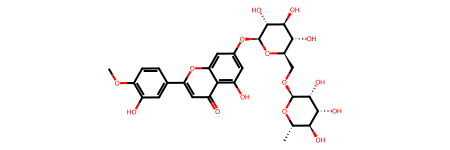

In [208]:
visualise_molecule('COc1ccc(-c2cc(=O)c3c(O)cc(O[C@@H]4O[C@H](CO[C@@H]5O[C@@H](C)[C@H](O)[C@@H](O)[C@H]5O)[C@@H](O)[C@H](O)[C@H]4O)cc3o2)cc1O')